# START
Welcome to the code of Group 7 for Project Course IEG 2026

In [6]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pypsa

## PART A

In [7]:
pd.options.future.infer_string = False
pd.options.mode.string_storage = "python"


# Capacity factor year can be chosen to be different
capacity_factor_year = 2017

def hourly_climatology(df):
    df = df[~((df.utc_time.dt.month == 2) & (df.utc_time.dt.day == 29))]
    df["month"] = df["utc_time"].dt.month
    df["day"] = df["utc_time"].dt.day
    df["hour"] = df["utc_time"].dt.hour
    
    result = (
        df.groupby(["month","day","hour"])["cf"]
        .mean()
        .reset_index()
    )
    result["timestamp"] = pd.to_datetime(dict(year=2017, month=result["month"], day=result["day"], hour=result["hour"]))

    result = result.sort_values("timestamp").reset_index(drop=True)

    # Create formatted column
    result["datetime"] = result["timestamp"].dt.strftime("%d/%m %H:%M")

    return result


def load_base_year_data(cf_year):
    """
    If cf_year = None then use 10 year average capacity factor data
    If cf_year is given then show the actual year
    """
    demand = pd.read_csv("../data/denmark_demand.csv", index_col=0)
    if cf_year is None:
        offshore_wind_cf = pd.read_csv("../data/averaged_offshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
        onshore_wind_cf = pd.read_csv("../data/averaged_onshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
        pv_cf = pd.read_csv("../data/averaged_pv_capacity_factor_denmark_hourly.csv", index_col=0)
        demand = pd.read_csv("../data/denmark_demand.csv", index_col=0)

        pv = pv_cf.rename(columns={"cf": "pv_cf"})
        onshore = onshore_wind_cf.rename(columns={"cf": "onshore_cf"})
        offshore = offshore_wind_cf.rename(columns={"cf": "offshore_cf"})

        work_df = pd.concat([pv, onshore, offshore, demand], axis=1)
        work_df.index = pd.to_datetime(
            "2015/" + work_df.index.astype(str),
            format="%Y/%d/%m %H:%M"
        )

        work_df.index = work_df.index.strftime("%d/%m/%Y %H:%M")

        work_df = work_df.rename(columns={"demand": "demand_mw"})
        return work_df
    else:

        offshore_wind_cf_df = pd.read_csv("../data/offshore_wind_capacity_factor_raw.csv",delimiter=";")
        onshore_wind_cf_df = pd.read_csv("../data/onshore_wind_capacity_factor_raw.csv", delimiter=";")
        pv_cf_df = pd.read_csv("../data/pv_capacity_factor_raw.csv", delimiter=";")

        # Convert ISO8601 to datetime
        offshore_wind_cf_df["utc_time"] = pd.to_datetime(offshore_wind_cf_df["utc_time"], utc=True, errors="raise")
        onshore_wind_cf_df["utc_time"] = pd.to_datetime(onshore_wind_cf_df["utc_time"], utc=True, errors="raise")
        pv_cf_df["utc_time"] = pd.to_datetime(pv_cf_df["utc_time"], utc=True, errors="raise")

        # Keep only time and Denmark
        df_pv = pv_cf_df[["utc_time", "DNK"]]
        df_onshore_wind = onshore_wind_cf_df[["utc_time", "DNK"]]
        df_offshore_wind = offshore_wind_cf_df[["utc_time", "DNK"]]

        # Filter out the exact year
        df_pv = df_pv[df_pv["utc_time"].dt.year == cf_year]
        df_onshore_wind = df_onshore_wind[df_onshore_wind["utc_time"].dt.year == cf_year]
        df_offshore_wind = df_offshore_wind[df_offshore_wind["utc_time"].dt.year == cf_year]

        # Rename columns
        df_pv = df_pv.rename(columns={"DNK": "cf"})
        df_onshore_wind = df_onshore_wind.rename(columns={"DNK": "cf"})
        df_offshore_wind = df_offshore_wind.rename(columns={"DNK": "cf"})
        
        # Remove year from capacity factor dataframes
        df_pv = hourly_climatology(df_pv)
        df_onshore_wind = hourly_climatology(df_onshore_wind)
        df_offshore_wind = hourly_climatology(df_offshore_wind)

        df_pv = df_pv[["datetime", "cf"]]
        df_onshore_wind = df_onshore_wind[["datetime", "cf"]]
        df_offshore_wind = df_offshore_wind[["datetime", "cf"]]

        # Rename columns
        df_pv = df_pv.rename(columns={"cf": "pv_cf"})
        df_onshore_wind = df_onshore_wind.rename(columns={"cf": "onshore_cf"})
        df_offshore_wind = df_offshore_wind.rename(columns={"cf": "offshore_cf"})

        # Set index
        df_pv = df_pv.set_index("datetime")
        df_onshore_wind = df_onshore_wind.set_index("datetime")
        df_offshore_wind = df_offshore_wind.set_index("datetime")

        # Concat the dataframes
        work_df = pd.concat([df_pv, df_onshore_wind, df_offshore_wind, demand], axis=1)
        work_df.index = pd.to_datetime(
            str(cf_year) + "/" + work_df.index.astype(str),
            format="%Y/%d/%m %H:%M"
        )

        work_df.index = work_df.index.strftime("%d/%m/%Y %H:%M")

        work_df = work_df.rename(columns={"demand": "demand_mw"})
        return work_df
        
work_df = load_base_year_data(capacity_factor_year)
work_df.index = pd.DatetimeIndex(
    pd.to_datetime(work_df.index, format="%d/%m/%Y %H:%M")
)


- A.1

In [8]:
# Technology lifetimes
onshore_wind_lifetime = 30 # years
offshore_wind_lifetime = 30 # years
pv_lifetime = 35 # years
ccgt_lifetime = 25 # years
ocgt_lifetime = 25 # years
biomass_chp_lifetime = 25 # years
coal_lifetime = 45 # years
oil_lifetime = 32 # years

# CAPEX
onshore_wind_capex = 1160000 # EUR/MW
offshore_wind_capex = 2500000 # EUR/MW
pv_capex = 500000 # EUR/MW
ccgt_capex = 900000 # EUR/MW
ocgt_capex = 600000 # EUR/MW
biomass_chp_capex = 5000000 # EUR/MW
coal_capex = 2750000 # EUR/MW
oil_capex = 900000 # EUR/MW

# Annualised capital costs
annualised_offshore_wind_capex = offshore_wind_capex / offshore_wind_lifetime # EUR/MW/year
annualised_onshore_wind_capex = onshore_wind_capex / onshore_wind_lifetime # EUR/MW/year
annualised_pv_capex = pv_capex / pv_lifetime # EUR/MW/year
annualised_ccgt_capex = ccgt_capex / ccgt_lifetime # EUR/MW/year
annualised_ocgt_capex = ocgt_capex / ocgt_lifetime # EUR/MW/year
annualised_chp_capex = biomass_chp_capex / biomass_chp_lifetime # EUR/MW/year
annualised_coal_capex = coal_capex / coal_lifetime # EUR/MW/year
annualised_oil_capex = oil_capex / oil_lifetime # EUR/MW/year


# Annual OPEX costs
offshore_wind_opex = 40000 # EUR/MW/year
onshore_wind_opex = 17000 # EUR/MW/year
pv_opex = 10500 # EUR/MW/year
ccgt_opex = 30500 # EUR/MW/year
ocgt_opex = 20000 # EUR/MW/year
chp_opex = 150000 # EUR/MW/year
coal_opex = 45 * 1000 # EUR/MW/year
oil_opex = 35 * 1000 # EUR/MW/year

# Efficiencies of generators
ccgt_efficiency = 0.57
ocgt_efficiency = 0.4
chp_efficiency = 0.25
coal_efficiency = 0.38
oil_efficiency = 0.3

# Input costs
gas_price = 30 # €/MWh
chp_input_price = 25 # €/MWh
coal_fuel_price = 27.5 # €/MWh
oil_fuel_price = 95 # €/MWh

# Setting up marginal generation costs
onshore_wind_marginal_cost = 4 # EUR/MWh
offshore_wind_marginal_cost = 2 # EUR/MWh
pv_marginal_cost = 0 # EUR/MWh
ccgt_marginal_cost = 4.5 + gas_price / ccgt_efficiency # EUR/MWh
ocgt_marginal_cost =  4.5 + gas_price / ocgt_efficiency # EUR/MWh
chp_marginal_cost = 15 + chp_input_price / chp_efficiency # EUR/MWh
coal_marginal_cost = 4 + coal_fuel_price / coal_efficiency # EUR/MWh
oil_marginal_cost = 5 + oil_fuel_price / oil_efficiency # EUR/MWh



# N


In [9]:
n = pypsa.Network()

# Set time snapshots
n.set_snapshots(work_df.index)

# Carriers
n.add(
    "Carrier",
    "OnshoreWind",
    co2_emissions=0,
    nice_name="Onshore wind"
)
n.add(
    "Carrier",
    "OffshoreWind",
    co2_emissions=0,
    nice_name="Offshore wind"
)
n.add(
    "Carrier",
    "PV",
    co2_emissions=0,
    nice_name="PV"
)
n.add(
    "Carrier",
    "AC",
    co2_emissions=0
)
n.add(
    "Carrier",
    "BiomassCHP",
    co2_emissions=0,
    nice_name="Biomass CHP"
)

n.add(
    "Carrier",
    "CCGT",
    co2_emissions=0,
    nice_name="CCGT"
)

n.add(
    "Carrier",
    "OCGT",
    co2_emissions=0,
    nice_name="OCGT"
)

n.add(
    "Carrier",
    "Coal",
    co2_emissions=0,
    nice_name="Coal"
)

n.add(
    "Carrier",
    "Oil",
    co2_emissions=0,
    nice_name="Oil"
)

# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
)

# Load
n.add(
    "Load",
    "DKLoad",
    bus="DK",
    p_set=work_df["demand_mw"].to_numpy()
)

# --- Generators ---
n.add(
    "Generator",
    "DKOffshoreWind",
    bus="DK",
    carrier="OffshoreWind",
    p_nom_extendable=True,
    p_nom=2650,
    p_max_pu = work_df["offshore_cf"].to_numpy(),
    marginal_cost=float(offshore_wind_marginal_cost),
    capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex),
)

n.add(
    "Generator",
    "DKOnshoreWind",
    bus="DK",
    carrier="OnshoreWind",
    p_nom_extendable=True,
    p_nom=4860,
    p_max_pu = work_df["onshore_cf"].to_numpy(),
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=float(annualised_onshore_wind_capex+ onshore_wind_opex),
)

n.add(
    "Generator",
    "DKPV",
    bus="DK",
    carrier="PV",
    p_nom_extendable=True,
    p_nom=4800,
    p_max_pu = work_df["pv_cf"].to_numpy(),
    marginal_cost=float(pv_marginal_cost),
    capital_cost=float(annualised_pv_capex + pv_opex),
)

n.add(
    "Generator",
    "DKBiomassCHP",
    bus="DK",
    carrier="BiomassCHP",
    p_nom=2000,
    p_nom_extendable=True,
    marginal_cost=float(chp_marginal_cost),
    capital_cost=float(annualised_chp_capex + chp_opex),
)

n.add(
    "Generator",
    "DKCCGT",
    bus="DK",
    carrier="CCGT",
    p_nom_extendable=True,
    p_nom=1750,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=float(annualised_ccgt_capex + ccgt_opex),
)

n.add(
    "Generator",
    "DKOCGT",
    bus="DK",
    carrier="OCGT",
    p_nom_extendable=True,
    p_nom=750,
    marginal_cost=float(ocgt_marginal_cost),
    capital_cost=float(annualised_ocgt_capex + ocgt_opex),
)

n.add(
    "Generator",
    "DKCoal",
    bus="DK",
    carrier="Coal",
    p_nom_extendable=True,
    p_nom=650,
    marginal_cost=coal_marginal_cost,
    capital_cost=annualised_coal_capex + coal_opex,
)

n.add(
    "Generator",
    "DKOil",
    bus="DK",
    carrier="Oil",
    p_nom_extendable=True,
    p_nom=300,
    marginal_cost=oil_marginal_cost,
    capital_cost=annualised_oil_capex + oil_opex,
)

In [10]:
n.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DKOffshoreWind,DKOnshoreWind,DKPV,DKBiomassCHP,DKCCGT,DKOCGT,DKCoal,DKOil
bus,DK,DK,DK,DK,DK,DK,DK,DK
carrier,OffshoreWind,OnshoreWind,PV,BiomassCHP,CCGT,OCGT,Coal,Oil
p_nom,2650.0,4860.0,4800.0,2000.0,1750.0,750.0,650.0,300.0
p_max_pu,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
capital_cost,123333.333333,55666.666667,24785.714286,350000.0,66500.0,44000.0,106111.111111,63125.0
marginal_cost,2.0,4.0,0.0,115.0,57.131579,79.5,76.368421,321.666667


In [11]:
# Solver
n.optimize(solver_name="gurobi",
           log_to_console=False
)

#n.statistics()

C:\Users\Study\AppData\Local\Temp\ipykernel_16820\2510442625.py:2: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00, 317.35it/s]
INFO:linopy.io: Writing time: 0.09s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2804680


INFO:gurobipy:Set parameter LicenseID to value 2804680


...

obj: 148928 rows, 70089 columns, 275965 nonzeros


INFO:gurobipy:obj: 148928 rows, 70089 columns, 275965 nonzeros


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 10.0 (19045.2))
INFO:gurobipy:
INFO:gurobipy:CPU model: AMD Ryzen 5 PRO 5650U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 6 physical cores, 12 logical processors, using up to 12 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 148928 rows, 70089 columns and 275965 nonzeros (Min)
INFO:gurobipy:Model fingerprint: 0x9f9f357e
INFO:gurobipy:Model has 61329 linear objective coefficients
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [1e-03, 1e+00]
INFO:gurobipy:  Objective range  [1e+00, 4e+05]
INFO:gurobipy:  Bounds range     [2e+09, 2e+09]
INFO:gurobipy:  RHS range        [2e+03, 6e+03]
INFO:gurobipy:Warning: Model contains large bounds
INFO:gurobipy:         Consider reformulating model or setting NumericFo

('ok', 'optimal')

In [12]:
# -----------------------------
# Global style for paper figures
# -----------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

### Winter week

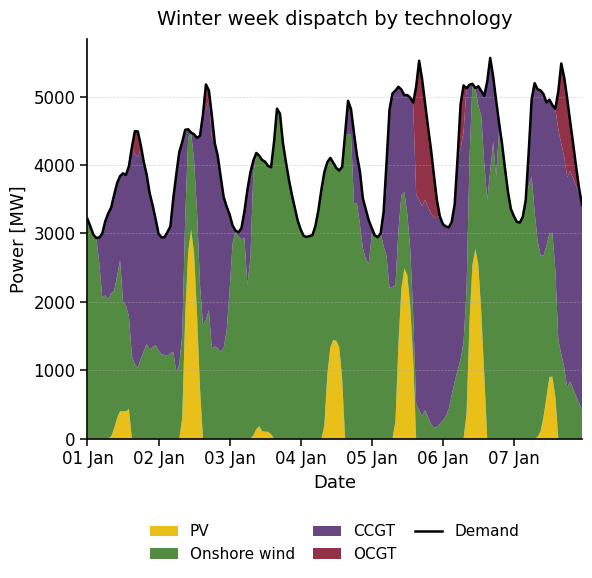

In [13]:
# -----------------------------
# Date range winter week
# -----------------------------
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-01-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-01-07 23:00:00")
else:
    start_date = pd.Timestamp("2015-01-01 00:00:00")
    end_date   = pd.Timestamp("2015-01-07 23:00:00")

# -----------------------------
# Fixed color map and order
# -----------------------------
tech_colors = {
    "PV": "#E7B800",
    "Onshore wind": "#407E2D",
    "Offshore wind": "#A00078",
    "Biomass CHP": "#8C564B",
    "CCGT": "#553375",
    "OCGT": "#851B35",
    "Coal": "#7E8083",
    "Oil": "#272727",
    "BESS": "#E6810E",
    "Demand": "#000000",
}

preferred_order = [
    "PV",
    "Onshore wind",
    "Offshore wind",
    "Biomass CHP",
    "CCGT",
    "OCGT",
    "Coal",
    "Oil",
]

# -----------------------------
# Dispatch preparation
# -----------------------------
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

tech_order = [c for c in preferred_order if c in dispatch_nice.columns]
dispatch_nice = dispatch_nice[tech_order]

# -----------------------------
# Slice time
# -----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_plot = work_df.loc[start_date:end_date, "demand_mw"].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)

# Remove technologies with zero dispatch in the plotted week
active_cols = dispatch_plot.columns[dispatch_plot.abs().sum(axis=0) > 1e-9]
dispatch_plot = dispatch_plot[active_cols]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6.2, 6.2))

x = dispatch_plot.index
y = [dispatch_plot[col].to_numpy() for col in dispatch_plot.columns]
stack_colors = [tech_colors.get(col, "#999999") for col in dispatch_plot.columns]

ax.stackplot(
    x, y,
    labels=dispatch_plot.columns,
    colors=stack_colors,
    alpha=0.90,
    linewidth=0.3
)

ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    color=tech_colors["Demand"],
    linewidth=1.8,
    label="Demand",
    zorder=5
)

# X-axis: daily ticks only
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# Labels and title
ax.set_ylabel("Power [MW]")
ax.set_xlabel("Date")
ax.set_title("Winter week dispatch by technology", pad=10)

# Clean styling
ax.margins(x=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

# Legend below plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
    handlelength=1.8,
    columnspacing=1.2
)

fig.tight_layout()
plt.show()

### Summer week

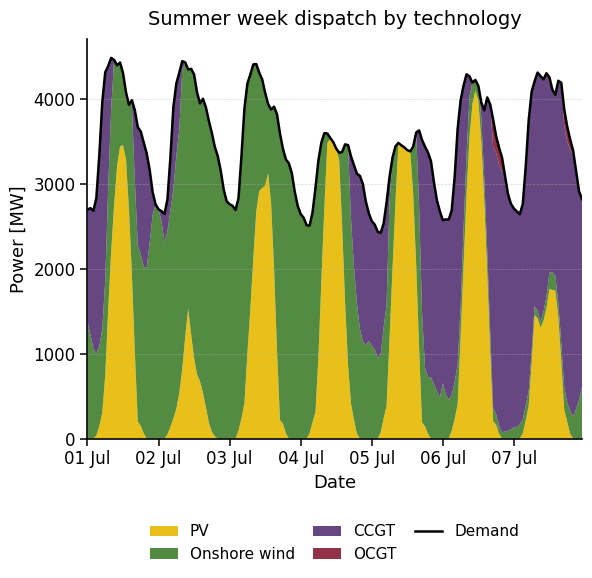

In [14]:
# -----------------------------
# Date range summer week
# -----------------------------
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-07-07 23:00:00")
else:
    start_date = pd.Timestamp("2015-07-01 00:00:00")
    end_date   = pd.Timestamp("2015-07-07 23:00:00")

# -----------------------------
# Fixed color map and order
# -----------------------------
tech_colors = {
    "PV": "#E7B800",
    "Onshore wind": "#407E2D",
    "Offshore wind": "#A00078",
    "Biomass CHP": "#8C564B",
    "CCGT": "#553375",
    "OCGT": "#851B35",
    "Coal": "#7E8083",
    "Oil": "#272727",
    "BESS": "#E6810E",
    "Demand": "#000000",
}

preferred_order = [
    "PV",
    "Onshore wind",
    "Offshore wind",
    "Biomass CHP",
    "CCGT",
    "OCGT",
    "Coal",
    "Oil",
]

# -----------------------------
# Dispatch preparation
# -----------------------------
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

tech_order = [c for c in preferred_order if c in dispatch_nice.columns]
dispatch_nice = dispatch_nice[tech_order]

# -----------------------------
# Slice time
# -----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_plot = work_df.loc[start_date:end_date, "demand_mw"].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)

# Remove technologies with zero dispatch in the plotted week
active_cols = dispatch_plot.columns[dispatch_plot.abs().sum(axis=0) > 1e-9]
dispatch_plot = dispatch_plot[active_cols]
# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6.2, 6.2))

x = dispatch_plot.index
y = [dispatch_plot[col].to_numpy() for col in dispatch_plot.columns]
stack_colors = [tech_colors.get(col, "#999999") for col in dispatch_plot.columns]

ax.stackplot(
    x, y,
    labels=dispatch_plot.columns,
    colors=stack_colors,
    alpha=0.90,
    linewidth=0.3
)

ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    color=tech_colors["Demand"],
    linewidth=1.8,
    label="Demand",
    zorder=5
)

# X-axis: daily ticks only
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# Labels
ax.set_ylabel("Power [MW]")
ax.set_xlabel("Date")
ax.set_title("Summer week dispatch by technology", pad=10)

# Cleaner look
ax.margins(x=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

# Legend below the plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
    handlelength=1.8,
    columnspacing=1.2
)

fig.tight_layout()
plt.show()

In [15]:
capacity = n.generators[["carrier", "p_nom_opt"]].copy()

# Map to nice names
capacity["Technology"] = capacity["carrier"].map(n.carriers.nice_name)

# Aggregate by technology
capacity_table = (
    capacity.groupby("Technology")["p_nom_opt"]
    .sum()
    .sort_values(ascending=False)
    .round(1)
)

if capacity_factor_year is not None:
    print(f"Year used for simulation: {capacity_factor_year}")
else:
    print("10 year average (2007 - 2017) was used for capacity factors")
print(capacity_table)

Year used for simulation: 2017
Technology
Onshore wind     8279.8
PV               6248.5
CCGT             3076.9
OCGT             2244.5
Coal                0.0
Biomass CHP         0.0
Oil                 0.0
Offshore wind       0.0
Name: p_nom_opt, dtype: float64


### Duration curves


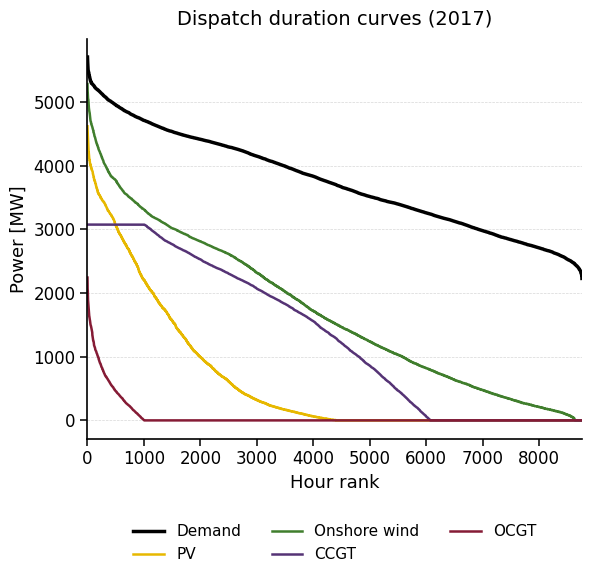

In [16]:
# -----------------------------
# Fixed color map and order
# -----------------------------
tech_colors = {
    "PV": "#E7B800",
    "Onshore wind": "#407E2D",
    "Offshore wind": "#A00078",
    "Biomass CHP": "#8C564B",
    "CCGT": "#553375",
    "OCGT": "#851B35",
    "Coal": "#7E8083",
    "Oil": "#272727",
    "BESS": "#E6810E",
    "Demand": "#000000",
}

preferred_order = [
    "Demand",
    "PV",
    "Onshore wind",
    "Offshore wind",
    "Biomass CHP",
    "CCGT",
    "OCGT",
    "Coal",
    "Oil",
]

# -----------------------------
# Build duration curves
# -----------------------------
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T
dispatch_nice["Demand"] = work_df["demand_mw"]

# Keep only technologies with nonzero annual dispatch
active_cols = dispatch_nice.columns[dispatch_nice.abs().sum(axis=0) > 1e-9]
dispatch_nice = dispatch_nice[active_cols]

duration_df = pd.DataFrame({
    col: dispatch_nice[col].sort_values(ascending=False).values
    for col in dispatch_nice.columns
})

# -----------------------------
# Fixed plotting order
# -----------------------------
plot_order = [c for c in preferred_order if c in duration_df.columns]
duration_df = duration_df[plot_order]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6.2, 6.2))

for col in duration_df.columns:
    if col == "Demand":
        ax.plot(
            duration_df.index,
            duration_df[col],
            linewidth=2.5,
            color=tech_colors["Demand"],
            label="Demand",
            zorder=5
        )
    elif col in ["PV", "Onshore wind", "Offshore wind"]:
        ax.plot(
            duration_df.index,
            duration_df[col],
            linewidth=1.8,
            color=tech_colors.get(col, "#999999"),
            label=col
        )
    else:
        ax.plot(
            duration_df.index,
            duration_df[col],
            linewidth=1.8,
            color=tech_colors.get(col, "#999999"),
            label=col
        )

# -----------------------------
# Labels and layout
# -----------------------------
ax.set_title("Dispatch duration curves (2017)", pad=10)
ax.set_xlabel("Hour rank")
ax.set_ylabel("Power [MW]")

ax.set_xlim(0, len(duration_df))
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

# Clean axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend below
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()

### Annual Electricity Mix

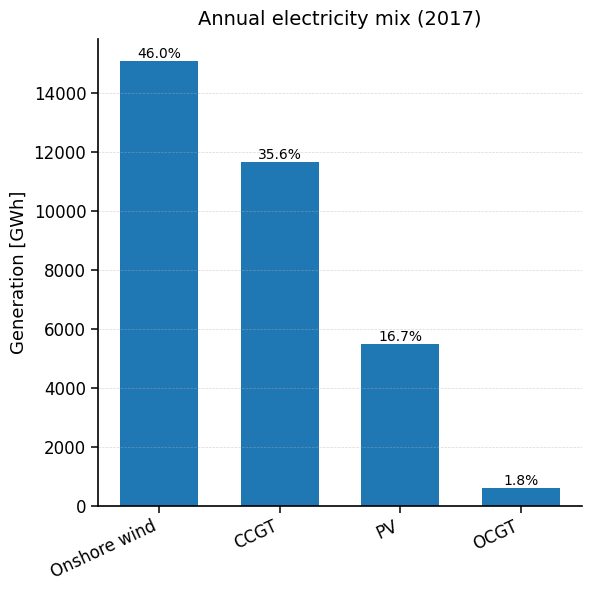

In [17]:
# -----------------------------
# Annual Electricity Mix
# -----------------------------
annual_generation = dispatch_nice.drop(columns="Demand", errors="ignore").sum(axis=0)

annual_generation_df = annual_generation.to_frame(name="generation_mwh")
annual_generation_df["generation_gwh"] = annual_generation_df["generation_mwh"] / 1000

annual_generation_df["share"] = (
    annual_generation_df["generation_mwh"] /
    annual_generation_df["generation_mwh"].sum()
)

annual_generation_df["share_percent"] = 100 * annual_generation_df["share"]

annual_generation_df = annual_generation_df.sort_values("generation_mwh", ascending=False)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6.2, 6.2))  # square

bars = ax.bar(
    annual_generation_df.index,
    annual_generation_df["generation_gwh"],
    width=0.65
)

# -----------------------------
# Add percentage labels on top
# -----------------------------
for bar, pct in zip(bars, annual_generation_df["share_percent"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# -----------------------------
# Labels and title
# -----------------------------
ax.set_ylabel("Generation [GWh]")
ax.set_title(f"Annual electricity mix ({capacity_factor_year})", pad=10)

# Clean axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Improve readability
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")

# Light grid
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# PART B

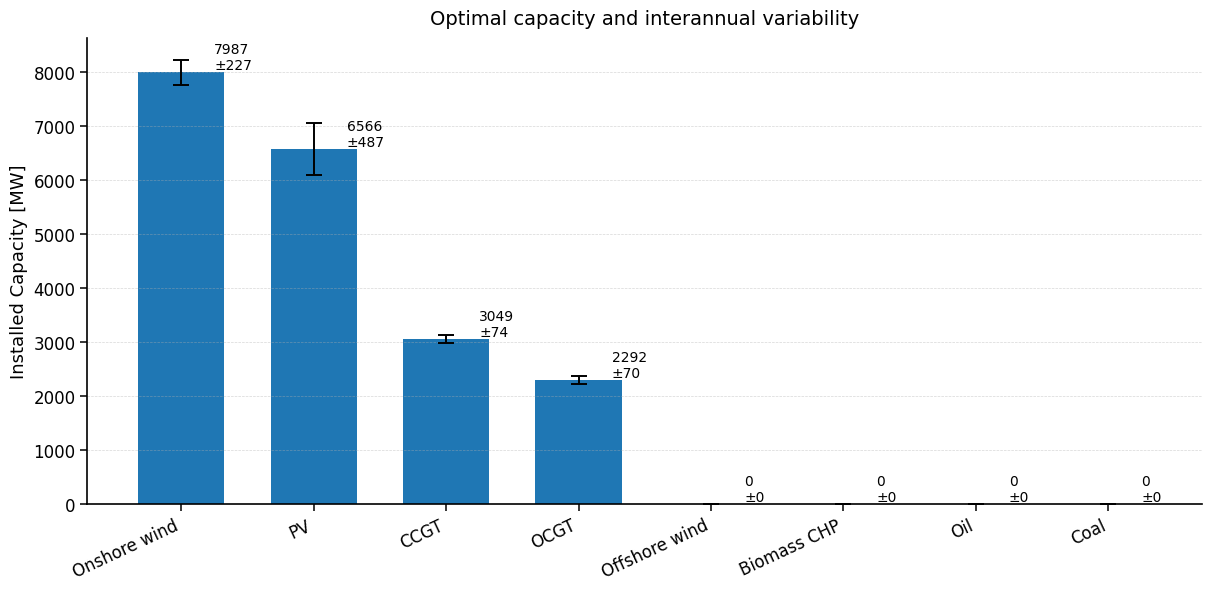

In [18]:
# Results from simulation

capacity_by_year = pd.DataFrame({
    2014: {
        "PV": 6508.6,
        "Onshore wind": 8025.9,
        "Offshore wind": 0.0,
        "CCGT": 2967.4,
        "OCGT": 2229.5,
        "Biomass CHP": 0.0,
        "Oil": 0.0,
        "Coal": 0.0
    },
    2015: {
        "PV": 6236.6,
        "Onshore wind": 7897.1,
        "Offshore wind": 0.0,
        "CCGT": 3012.6,
        "OCGT": 2380.4,
        "Biomass CHP": 0.0,
        "Oil": 0.0,
        "Coal": 0.0
    },
    2016: {
        "PV": 7271.3,
        "Onshore wind": 7744.9,
        "Offshore wind": 0.0,
        "CCGT": 3137.5,
        "OCGT": 2315.1,
        "Biomass CHP": 0.0,
        "Oil": 0.0,
        "Coal": 0.0
    },
    2017: {
        "PV": 6248.5,
        "Onshore wind": 8279.8,
        "Offshore wind": 0.0,
        "CCGT": 3076.9,
        "OCGT": 2244.5,
        "Biomass CHP": 0.0,
        "Oil": 0.0,
        "Coal": 0.0
    }
}).T

import numpy as np
# -----------------------------
# Data
# -----------------------------
mean_capacity = capacity_by_year.mean()
std_capacity = capacity_by_year.std()

# Sort by mean capacity
mean_capacity = mean_capacity.sort_values(ascending=False)
std_capacity = std_capacity[mean_capacity.index]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12.4, 6.2))  # square

x = np.arange(len(mean_capacity))

bars = ax.bar(
    x,
    mean_capacity.values,
    yerr=std_capacity.values,
    capsize=6,
    width=0.65,
    error_kw={
        "elinewidth": 1.4,
        "capthick": 1.4
    }
)

# -----------------------------
# Annotate values (mean ± std)
# -----------------------------
offset = 0.25  # horizontal shift

for i, (mean, std) in enumerate(zip(mean_capacity, std_capacity)):
    ax.text(
        i + offset,          # shift to the right
        mean,
        f"{mean:.0f}\n±{std:.0f}",
        ha="left",           # align text from left edge
        va="bottom",
        fontsize=10
    )

# -----------------------------
# Labels and title
# -----------------------------
ax.set_ylabel("Installed Capacity [MW]")
ax.set_title("Optimal capacity and interannual variability", pad=10)

ax.set_xticks(x)
ax.set_xticklabels(mean_capacity.index, rotation=25, ha="right")

# Clean axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Light grid
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# PART C

In [19]:
# Add battery variables
battery_lifetime = 17

# Battery CAPEX
battery_capex = 450000 # EUR/MW

# Annualised capital costs
annualised_battery_inverter_capex = battery_capex / battery_lifetime # EUR/MW/year
annualised_battery_energy_capex = 0.5 # EUR/MWh/year

# Annual OPEX costs
battery_opex = 10000 # EUR/MW/year

# Battery energy-to-power ratio
battery_hours = 2

# Efficiencies
battery_inverter_efficiency = 0.96

# N1   

In [20]:
n1 = pypsa.Network()

# Set time snapshots
n1.set_snapshots(work_df.index)

# Carriers
n1  .add(
    "Carrier",
    "OnshoreWind",
    co2_emissions=0,
    nice_name="Onshore wind"
)
n1.add(
    "Carrier",
    "OffshoreWind",
    co2_emissions=0,
    nice_name="Offshore wind"
)
n1.add(
    "Carrier",
    "PV",
    co2_emissions=0,
    nice_name="PV"
)
n1.add(
    "Carrier",
    "AC",
    co2_emissions=0
)
n1.add(
    "Carrier",
    "BiomassCHP",
    co2_emissions=0,
    nice_name="Biomass CHP"
)
n1.add(
    "Carrier",
    "CCGT",
    co2_emissions=0,
    nice_name="CCGT"
)

n1.add(
    "Carrier",
    "OCGT",
    co2_emissions=0,
    nice_name="OCGT"
)

n1.add(
    "Carrier",
    "Coal",
    co2_emissions=0,
    nice_name="Coal"
)

n1.add(
    "Carrier",
    "Oil",
    co2_emissions=0,
    nice_name="Oil"
)

n1.add(
    "Carrier",
    "BESS",
    co2_emissions=0,
    nice_name="BESS"
)

n1.add(
    "Carrier",
    "BESS4h",
    co2_emissions=0,
    nice_name="BESS 4H"
)

# --- Buses ---
n1.add(
    "Bus",
    "DK",
    carrier="AC",
)

# Load
n1.add(
    "Load",
    "DKLoad",
    bus="DK",
    p_set=work_df["demand_mw"].to_numpy()
)

# --- Generators ---
n1.add(
    "Generator",
    "DKOffshoreWind",
    bus="DK",
    carrier="OffshoreWind",
    p_nom_extendable=True,
    p_nom=2650,
    p_max_pu = work_df["offshore_cf"].to_numpy(),
    marginal_cost=float(offshore_wind_marginal_cost),
    capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex),
)

n1.add(
    "Generator",
    "DKOnshoreWind",
    bus="DK",
    carrier="OnshoreWind",
    p_nom_extendable=True,
    p_nom=4860,
    p_max_pu = work_df["onshore_cf"].to_numpy(),
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=float(annualised_onshore_wind_capex + onshore_wind_opex),
)

n1.add(
    "Generator",
    "DKPV",
    bus="DK",
    carrier="PV",
    p_nom_extendable=True,
    p_nom=4800,
    p_max_pu = work_df["pv_cf"].to_numpy(),
    marginal_cost=float(pv_marginal_cost),
    capital_cost=float(annualised_pv_capex + pv_opex),
)

n1.add(
    "Generator",
    "DKBiomassCHP",
    bus="DK",
    carrier="BiomassCHP",
    p_nom_extendable=True,
    p_nom=2000,
    marginal_cost=float(chp_marginal_cost),
    capital_cost=float(annualised_chp_capex + chp_opex),
)

n1.add(
    "Generator",
    "DKCCGT",
    bus="DK",
    carrier="CCGT",
    p_nom_extendable=True,
    p_nom=1750,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=float(annualised_ccgt_capex + ccgt_opex),
)

n1.add(
    "Generator",
    "DKOCGT",
    bus="DK",
    carrier="OCGT",
    p_nom_extendable=True,
    p_nom=750,
    marginal_cost=float(ocgt_marginal_cost),
    capital_cost=float(annualised_ocgt_capex + ocgt_opex),
)

n1.add(
    "Generator",
    "DKCoal",
    bus="DK",
    carrier="Coal",
    p_nom_extendable=True,
    p_nom=650,
    marginal_cost=coal_marginal_cost,
    capital_cost=annualised_coal_capex + coal_opex,
)

n1.add(
    "Generator",
    "DKOil",
    bus="DK",
    carrier="Oil",
    p_nom_extendable=True,
    p_nom=300,
    marginal_cost=oil_marginal_cost,
    capital_cost=annualised_oil_capex + oil_opex,
)

# --- Storage Units ---
battery_total_annualised_capex = annualised_battery_inverter_capex + battery_opex

n1.add(
    "StorageUnit",
    "DKBESS",
    bus="DK",
    carrier="BESS",
    p_nom_extendable=True,
    p_nom=100,
    max_hours=battery_hours,
    efficiency_store=battery_inverter_efficiency,
    efficiency_dispatch=battery_inverter_efficiency,
    capital_cost=battery_total_annualised_capex,
    marginal_cost=0.0,
    cyclic_state_of_charge=True
)

In [21]:
n1.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DKOffshoreWind,DKOnshoreWind,DKPV,DKBiomassCHP,DKCCGT,DKOCGT,DKCoal,DKOil
bus,DK,DK,DK,DK,DK,DK,DK,DK
carrier,OffshoreWind,OnshoreWind,PV,BiomassCHP,CCGT,OCGT,Coal,Oil
p_nom,2650.0,4860.0,4800.0,2000.0,1750.0,750.0,650.0,300.0
p_max_pu,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
capital_cost,123333.333333,55666.666667,24785.714286,350000.0,66500.0,44000.0,106111.111111,63125.0
marginal_cost,2.0,4.0,0.0,115.0,57.131579,79.5,76.368421,321.666667


In [22]:
n1.storage_units[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DKBESS
bus,DK
carrier,BESS
p_nom,100.0
p_max_pu,1.0
capital_cost,36470.588235
marginal_cost,0.0


## SOLVE N1

In [23]:
# Solver
n1.optimize(solver_name="gurobi",
           log_to_console=False
           )

C:\Users\Study\AppData\Local\Temp\ipykernel_16820\3612210639.py:2: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 390.69it/s]
INFO:linopy.io: Writing time: 0.13s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2804680


INFO:gurobipy:Set parameter LicenseID to value 2804680


...

obj: 210249 rows, 96370 columns, 407366 nonzeros


INFO:gurobipy:obj: 210249 rows, 96370 columns, 407366 nonzeros


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 10.0 (19045.2))
INFO:gurobipy:
INFO:gurobipy:CPU model: AMD Ryzen 5 PRO 5650U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 6 physical cores, 12 logical processors, using up to 12 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 210249 rows, 96370 columns and 407366 nonzeros (Min)
INFO:gurobipy:Model fingerprint: 0x31502f18
INFO:gurobipy:Model has 61330 linear objective coefficients
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [1e-03, 2e+00]
INFO:gurobipy:  Objective range  [1e+00, 4e+05]
INFO:gurobipy:  Bounds range     [2e+09, 2e+09]
INFO:gurobipy:  RHS range        [2e+03, 6e+03]
INFO:gurobipy:Warning: Model contains large bounds
INFO:gurobipy:         Consider reformulating model or setting NumericFo

('ok', 'optimal')

## Winter week

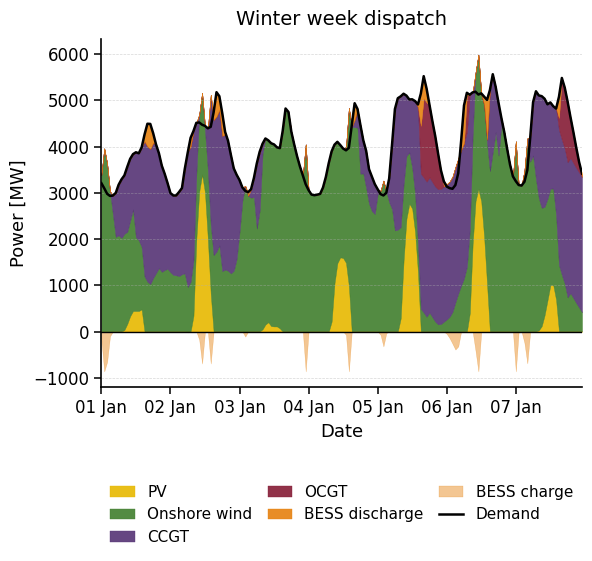

In [24]:
# -----------------------------
# Date range winter week
# -----------------------------
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-01-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-01-07 23:00:00")
else:
    start_date = pd.Timestamp("2015-01-01 00:00:00")
    end_date   = pd.Timestamp("2015-01-07 23:00:00")

# -----------------------------
# Fixed color map
# -----------------------------
tech_colors = {
    "PV": "#E7B800",
    "Onshore wind": "#407E2D",
    "Offshore wind": "#A00078",
    "Biomass CHP": "#8C564B",
    "CCGT": "#553375",
    "OCGT": "#851B35",
    "Coal": "#7E8083",
    "Oil": "#272727",
    "BESS": "#E6810E",
    "Demand": "#000000",
}

# -----------------------------
# GENERATORS
# -----------------------------
dispatch = n1.generators_t.p.copy()

carrier_series = n1.generators.carrier
nice_name_map = n1.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)
dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Fixed plotting order
preferred_order = [
    "PV", "Onshore wind", "Offshore wind",
    "Biomass CHP", "CCGT", "OCGT", "Coal", "Oil"
]
tech_order = [c for c in preferred_order if c in dispatch_nice.columns]
dispatch_nice = dispatch_nice[tech_order]

# -----------------------------
# STORAGE UNITS
# -----------------------------
storage_p = n1.storage_units_t.p.copy()

if not storage_p.empty:
    storage_nice_map = n1.storage_units.carrier.map(n1.carriers.nice_name).to_dict()

    storage_nice = storage_p.rename(
        columns=lambda s: storage_nice_map.get(s, s)
    )
    storage_nice = storage_nice.T.groupby(level=0).sum().T

    storage_discharge = storage_nice.clip(lower=0)
    storage_charge = storage_nice.clip(upper=0)
else:
    storage_discharge = pd.DataFrame(index=dispatch_nice.index)
    storage_charge = pd.DataFrame(index=dispatch_nice.index)

# -----------------------------
# Slice time
# -----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_plot = work_df.loc[start_date:end_date, "demand_mw"].copy()
storage_discharge_plot = storage_discharge.loc[start_date:end_date].copy()
storage_charge_plot = storage_charge.loc[start_date:end_date].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)
storage_discharge_plot.index = pd.to_datetime(storage_discharge_plot.index)
storage_charge_plot.index = pd.to_datetime(storage_charge_plot.index)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6.2, 6.2))
x = dispatch_plot.index

# Positive stack: generators
pos_cum = np.zeros(len(x))
for col in tech_order:
    if col in dispatch_plot.columns:
        y = dispatch_plot[col].to_numpy()
        if np.any(np.abs(y) > 1e-9):
            ax.fill_between(
                x, pos_cum, pos_cum + y,
                color=tech_colors.get(col, "#999999"),
                alpha=0.90,
                linewidth=0.3,
                label=col
            )
            pos_cum = pos_cum + y

# Positive stack: storage discharge
for col in storage_discharge_plot.columns:
    y = storage_discharge_plot[col].to_numpy()
    if np.any(np.abs(y) > 1e-9):
        ax.fill_between(
            x, pos_cum, pos_cum + y,
            color=tech_colors["BESS"],
            alpha=0.90,
            linewidth=0.3,
            label=f"{col} discharge"
        )
        pos_cum = pos_cum + y

# Negative stack: storage charge
neg_cum = np.zeros(len(x))
for col in storage_charge_plot.columns:
    y = storage_charge_plot[col].to_numpy()
    if np.any(np.abs(y) > 1e-9):
        ax.fill_between(
            x, neg_cum, neg_cum + y,
            color=tech_colors["BESS"],
            alpha=0.45,
            linewidth=0.3,
            label=f"{col} charge"
        )
        neg_cum = neg_cum + y

# Demand line
ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    color=tech_colors["Demand"],
    linewidth=1.8,
    label="Demand",
    zorder=5
)

ax.axhline(0, color="black", linewidth=1.0)

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Date")
ax.set_title("Winter week dispatch", pad=10)

ax.margins(x=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.24),
    ncol=3,
    frameon=False,
    handlelength=1.6,
    columnspacing=1.0
)

fig.tight_layout()
plt.show()

## Summer week

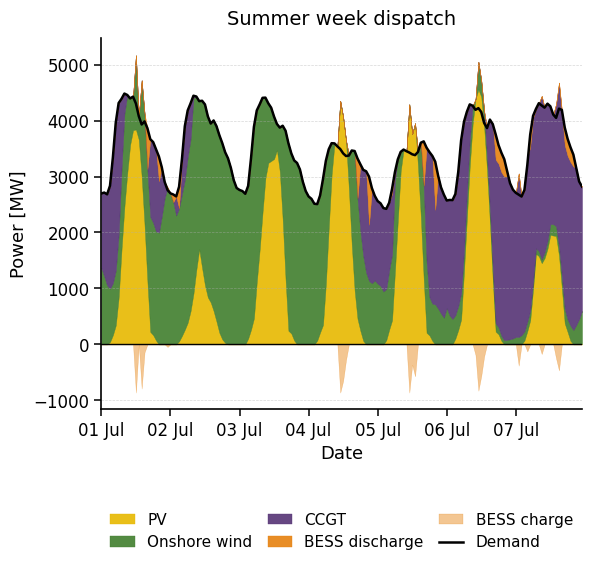

In [25]:
# -----------------------------
# Date range summer week
# -----------------------------
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-07-07 23:00:00")
else:
    start_date = pd.Timestamp("2015-07-01 00:00:00")
    end_date   = pd.Timestamp("2015-07-07 23:00:00")

# -----------------------------
# Fixed color map
# -----------------------------
tech_colors = {
    "PV": "#E7B800",
    "Onshore wind": "#407E2D",
    "Offshore wind": "#A00078",
    "Biomass CHP": "#8C564B",
    "CCGT": "#553375",
    "OCGT": "#851B35",
    "Coal": "#7E8083",
    "Oil": "#272727",
    "BESS": "#E6810E",
    "Demand": "#000000",
}

# -----------------------------
# GENERATORS
# -----------------------------
dispatch = n1.generators_t.p.copy()

carrier_series = n1.generators.carrier
nice_name_map = n1.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)
dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

preferred_order = [
    "PV", "Onshore wind", "Offshore wind",
    "Biomass CHP", "CCGT", "OCGT", "Coal", "Oil"
]
tech_order = [c for c in preferred_order if c in dispatch_nice.columns]
dispatch_nice = dispatch_nice[tech_order]

# -----------------------------
# STORAGE UNITS
# -----------------------------
storage_p = n1.storage_units_t.p.copy()

if not storage_p.empty:
    storage_nice_map = n1.storage_units.carrier.map(n1.carriers.nice_name).to_dict()

    storage_nice = storage_p.rename(
        columns=lambda s: storage_nice_map.get(s, s)
    )
    storage_nice = storage_nice.T.groupby(level=0).sum().T

    storage_discharge = storage_nice.clip(lower=0)
    storage_charge = storage_nice.clip(upper=0)
else:
    storage_discharge = pd.DataFrame(index=dispatch_nice.index)
    storage_charge = pd.DataFrame(index=dispatch_nice.index)

# -----------------------------
# Slice time
# -----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_plot = work_df.loc[start_date:end_date, "demand_mw"].copy()
storage_discharge_plot = storage_discharge.loc[start_date:end_date].copy()
storage_charge_plot = storage_charge.loc[start_date:end_date].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)
storage_discharge_plot.index = pd.to_datetime(storage_discharge_plot.index)
storage_charge_plot.index = pd.to_datetime(storage_charge_plot.index)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6.2, 6.2))
x = dispatch_plot.index

# Positive stack: generators
pos_cum = np.zeros(len(x))
for col in tech_order:
    if col in dispatch_plot.columns:
        y = dispatch_plot[col].to_numpy()
        if np.any(np.abs(y) > 1e-9):
            ax.fill_between(
                x, pos_cum, pos_cum + y,
                color=tech_colors.get(col, "#999999"),
                alpha=0.90,
                linewidth=0.3,
                label=col
            )
            pos_cum = pos_cum + y

# Positive stack: storage discharge
for col in storage_discharge_plot.columns:
    y = storage_discharge_plot[col].to_numpy()
    if np.any(np.abs(y) > 1e-9):
        ax.fill_between(
            x, pos_cum, pos_cum + y,
            color=tech_colors["BESS"],
            alpha=0.90,
            linewidth=0.3,
            label=f"{col} discharge"
        )
        pos_cum = pos_cum + y

# Negative stack: storage charge
neg_cum = np.zeros(len(x))
for col in storage_charge_plot.columns:
    y = storage_charge_plot[col].to_numpy()
    if np.any(np.abs(y) > 1e-9):
        ax.fill_between(
            x, neg_cum, neg_cum + y,
            color=tech_colors["BESS"],
            alpha=0.45,
            linewidth=0.3,
            label=f"{col} charge"
        )
        neg_cum = neg_cum + y

# Demand line
ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    color=tech_colors["Demand"],
    linewidth=1.8,
    label="Demand",
    zorder=5
)

ax.axhline(0, color="black", linewidth=1.0)

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Date")
ax.set_title("Summer week dispatch", pad=10)

ax.margins(x=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.24),
    ncol=3,
    frameon=False,
    handlelength=1.6,
    columnspacing=1.0
)

fig.tight_layout()
plt.show()

In [26]:
# Generators
gen_capacity = n.generators[["carrier", "p_nom_opt"]].copy()
gen_capacity["Technology"] = gen_capacity["carrier"].map(n.carriers.nice_name)

# Storage units
su_capacity = n.storage_units[["carrier", "p_nom_opt"]].copy()
su_capacity["Technology"] = su_capacity["carrier"].map(n.carriers.nice_name)

# Combine
capacity = pd.concat([
    gen_capacity[["Technology", "p_nom_opt"]],
    su_capacity[["Technology", "p_nom_opt"]]
], axis=0)

# Aggregate by technology
capacity_table = (
    capacity.groupby("Technology")["p_nom_opt"]
    .sum()
    .sort_values(ascending=False)
    .round(1)
)

if capacity_factor_year is not None:
    print(f"Year used for simulation: {capacity_factor_year}")
else:
    print("10 year average (2007 - 2017) was used for capacity factors")

print(capacity_table)

Year used for simulation: 2017
Technology
Onshore wind     8279.8
PV               6248.5
CCGT             3076.9
OCGT             2244.5
Coal                0.0
Biomass CHP         0.0
Oil                 0.0
Offshore wind       0.0
Name: p_nom_opt, dtype: float64


## Dispatch duration and anual mix curve

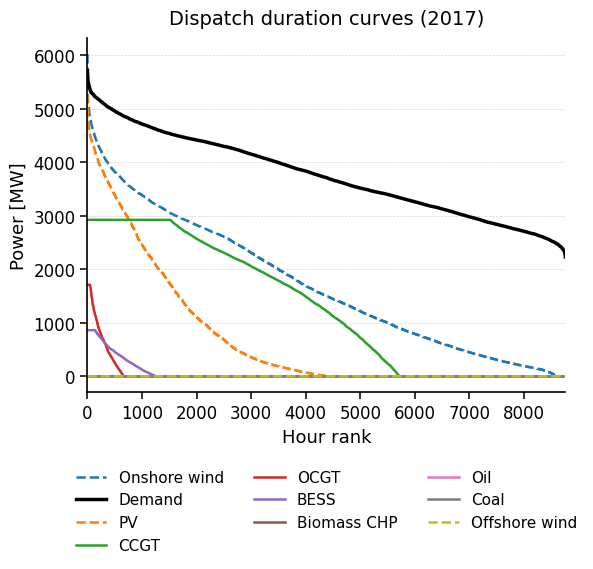

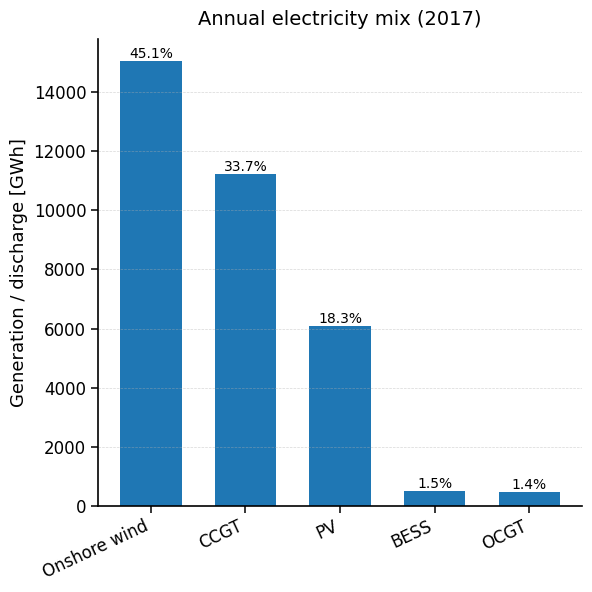


Annual storage operation:


,discharge_mwh,discharge_gwh,charge_mwh,charge_gwh
name,,,,
BESS,507059.339458,507.059339,550194.595766,550.194596


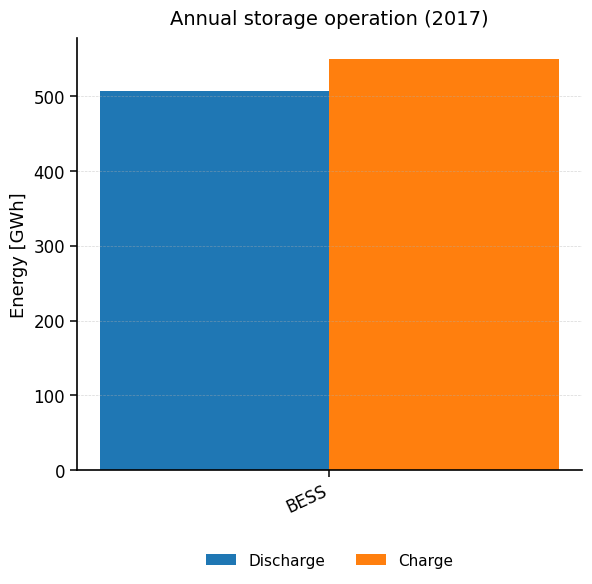

In [27]:
# -----------------------------
# GENERATOR DISPATCH
# -----------------------------
gen_dispatch = n1.generators_t.p.copy()

carrier_series = n1.generators.carrier
nice_name_map = n1.carriers.nice_name.to_dict()

dispatch_nice = gen_dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# -----------------------------
# STORAGE DISPATCH
# Add BESS discharge as supply
# -----------------------------
storage_dispatch = n1.storage_units_t.p.copy()

if not storage_dispatch.empty:
    su_carrier_series = n1.storage_units.carrier

    storage_dispatch_nice = storage_dispatch.rename(
        columns=lambda s: nice_name_map.get(su_carrier_series[s], su_carrier_series[s])
    )
    storage_dispatch_nice = storage_dispatch_nice.T.groupby(level=0).sum().T

    # Positive = discharge, Negative = charge
    storage_discharge = storage_dispatch_nice.clip(lower=0)
    storage_charge = -storage_dispatch_nice.clip(upper=0)

    # Add BESS discharge to main dispatch dataframe for the two key figures
    # This is what makes BESS appear in duration curves and annual mix
    for col in storage_discharge.columns:
        if col in dispatch_nice.columns:
            dispatch_nice[col] = dispatch_nice[col] + storage_discharge[col]
        else:
            dispatch_nice[col] = storage_discharge[col]
else:
    storage_discharge = pd.DataFrame(index=dispatch_nice.index)
    storage_charge = pd.DataFrame(index=dispatch_nice.index)

# Add demand for duration curves
dispatch_nice["Demand"] = work_df["demand_mw"]

# ============================================================
# 1) DISPATCH DURATION CURVES (WITH BESS DISCHARGE)
# ============================================================
duration_df = pd.DataFrame({
    col: dispatch_nice[col].sort_values(ascending=False).values
    for col in dispatch_nice.columns
})

# Sort by peak contribution
peak_order = duration_df.max().sort_values(ascending=False).index
duration_df = duration_df[peak_order]

fig, ax = plt.subplots(figsize=(6.2, 6.2))

for col in duration_df.columns:
    if col == "Demand":
        ax.plot(
            duration_df.index,
            duration_df[col],
            linewidth=2.5,
            color="black",
            label="Demand",
            zorder=5
        )
    elif "wind" in col.lower() or "pv" in col.lower():
        ax.plot(
            duration_df.index,
            duration_df[col],
            linestyle="--",
            linewidth=1.8,
            label=col
        )
    else:
        ax.plot(
            duration_df.index,
            duration_df[col],
            linewidth=1.8,
            label=col
        )

ax.set_title(f"Dispatch duration curves ({capacity_factor_year})", pad=10)
ax.set_xlabel("Hour rank")
ax.set_ylabel("Power [MW]")

ax.set_xlim(0, len(duration_df))
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()

# ============================================================
# 2) ANNUAL ELECTRICITY MIX (WITH BESS DISCHARGE)
# ============================================================
annual_generation = dispatch_nice.drop(columns="Demand", errors="ignore").sum(axis=0)

annual_generation_df = annual_generation.to_frame(name="generation_mwh")
annual_generation_df["generation_gwh"] = annual_generation_df["generation_mwh"] / 1000
annual_generation_df["share"] = (
    annual_generation_df["generation_mwh"] /
    annual_generation_df["generation_mwh"].sum()
)
annual_generation_df["share_percent"] = 100 * annual_generation_df["share"]

annual_generation_df = annual_generation_df.sort_values("generation_mwh", ascending=False)

# Remove zero-generation technologies
annual_generation_df = annual_generation_df[annual_generation_df["generation_mwh"] > 0]

fig, ax = plt.subplots(figsize=(6.2, 6.2))

bars = ax.bar(
    annual_generation_df.index,
    annual_generation_df["generation_gwh"],
    width=0.65
)

# Add percentage labels
for bar, pct in zip(bars, annual_generation_df["share_percent"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylabel("Generation / discharge [GWh]")
ax.set_title(f"Annual electricity mix ({capacity_factor_year})", pad=10)

plt.setp(ax.get_xticklabels(), rotation=25, ha="right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# ============================================================
# 3) ANNUAL STORAGE CHARGING / DISCHARGING
# Storage shown separately as operational summary
# ============================================================
if not storage_dispatch.empty:
    annual_storage_discharge = storage_discharge.sum(axis=0)
    annual_storage_charge = storage_charge.sum(axis=0)

    annual_storage_df = pd.DataFrame({
        "discharge_mwh": annual_storage_discharge,
        "discharge_gwh": annual_storage_discharge / 1000,
        "charge_mwh": annual_storage_charge,
        "charge_gwh": annual_storage_charge / 1000,
    }).sort_values("discharge_mwh", ascending=False)

    annual_storage_df = annual_storage_df[
        (annual_storage_df["discharge_mwh"] > 0) |
        (annual_storage_df["charge_mwh"] > 0)
    ]

    print("\nAnnual storage operation:")
    display(annual_storage_df)

    fig, ax = plt.subplots(figsize=(6.2, 6.2))

    x = np.arange(len(annual_storage_df))
    width = 0.36

    ax.bar(
        x - width/2,
        annual_storage_df["discharge_gwh"],
        width=width,
        label="Discharge"
    )
    ax.bar(
        x + width/2,
        annual_storage_df["charge_gwh"],
        width=width,
        label="Charge"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(annual_storage_df.index, rotation=25, ha="right")

    ax.set_ylabel("Energy [GWh]")
    ax.set_title(f"Annual storage operation ({capacity_factor_year})", pad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.16),
        ncol=2,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

else:
    print("No storage units found in the model.")

# Part D

### NEW COUNTRIES
Norway

Sweden

Great Britain

In [28]:
# Don't allow to have the 10 year average anymore as a CF setting
capacity_factor_year = 2017
if capacity_factor_year is None:
    capacity_factor_year = 2015

# Collect demand and capacity factors of new countries
offshore_wind_cf_df_raw = pd.read_csv("../data/offshore_wind_capacity_factor_raw.csv",delimiter=";")
onshore_wind_cf_df_raw = pd.read_csv("../data/onshore_wind_capacity_factor_raw.csv", delimiter=";")
pv_cf_df_raw = pd.read_csv("../data/pv_capacity_factor_raw.csv", delimiter=";")
el_demand_raw = pd.read_csv("../data/electricity_demand.csv", delimiter=";")

# Collect hydro values
hydro_hourly = pd.read_csv("../data/hydro_hourly.csv",delimiter=",")
hydro_hourly["utc_time"] = pd.to_datetime(hydro_hourly["utc_time"], utc=True, errors="raise")


# Convert ISO8601 to datetime
offshore_wind_cf_df_raw["utc_time"] = pd.to_datetime(offshore_wind_cf_df_raw["utc_time"], utc=True, errors="raise")
onshore_wind_cf_df_raw["utc_time"] = pd.to_datetime(onshore_wind_cf_df_raw["utc_time"], utc=True, errors="raise")
pv_cf_df_raw["utc_time"] = pd.to_datetime(pv_cf_df_raw["utc_time"], utc=True, errors="raise")
el_demand_raw["utc_time"] = pd.to_datetime(el_demand_raw["utc_time"], utc=True, errors="raise")

# Filter out the exact year
pv_cf_df_raw = pv_cf_df_raw[pv_cf_df_raw["utc_time"].dt.year == capacity_factor_year]
onshore_wind_cf_df_raw = onshore_wind_cf_df_raw[onshore_wind_cf_df_raw["utc_time"].dt.year == capacity_factor_year]
offshore_wind_cf_df_raw = offshore_wind_cf_df_raw[offshore_wind_cf_df_raw["utc_time"].dt.year == capacity_factor_year]
el_demand_raw["utc_time"] = el_demand_raw["utc_time"].apply(lambda t: t.replace(year=capacity_factor_year))
hydro_hourly = hydro_hourly[hydro_hourly["utc_time"].dt.year == capacity_factor_year]

# Norway
df_pv_no = pv_cf_df_raw[["utc_time", "NOR"]]
df_onshore_wind_no = onshore_wind_cf_df_raw[["utc_time", "NOR"]]
df_offshore_wind_no = offshore_wind_cf_df_raw[["utc_time", "NOR"]]
el_demand_no = el_demand_raw[["utc_time", "NOR"]]
hydro_df_no = hydro_hourly["NO"]

# Denmark
df_pv_dk = pv_cf_df_raw[["utc_time", "DNK"]]
df_onshore_wind_dk = onshore_wind_cf_df_raw[["utc_time", "DNK"]]
df_offshore_wind_dk = offshore_wind_cf_df_raw[["utc_time", "DNK"]]
el_demand_dk = el_demand_raw[["utc_time", "DNK"]]

# Sweden
df_pv_swe = pv_cf_df_raw[["utc_time", "SWE"]]
df_onshore_wind_swe = onshore_wind_cf_df_raw[["utc_time", "SWE"]]
df_offshore_wind_swe = offshore_wind_cf_df_raw[["utc_time", "SWE"]]
el_demand_swe = el_demand_raw[["utc_time", "SWE"]]
hydro_df_se = hydro_hourly["SE"]

# Great Britain
df_pv_gbr = pv_cf_df_raw[["utc_time", "GBR"]]
df_onshore_wind_gbr = onshore_wind_cf_df_raw[["utc_time", "GBR"]]
df_offshore_wind_gbr = offshore_wind_cf_df_raw[["utc_time", "GBR"]]
el_demand_gbr = el_demand_raw[["utc_time", "GBR"]]
hydro_df_gb = hydro_hourly["GB"]

# Rename columns
df_pv_dk = df_pv_dk.rename(columns={"DNK": "cf"})
df_onshore_wind_dk = df_onshore_wind_dk.rename(columns={"DNK": "cf"})
df_offshore_wind_dk = df_offshore_wind_dk.rename(columns={"DNK": "cf"})

df_pv_no = df_pv_no.rename(columns={"NOR": "cf"})
df_onshore_wind_no = df_onshore_wind_no.rename(columns={"NOR": "cf"})
df_offshore_wind_no = df_offshore_wind_no.rename(columns={"NOR": "cf"})

df_pv_swe = df_pv_swe.rename(columns={"SWE": "cf"})
df_onshore_wind_swe = df_onshore_wind_swe.rename(columns={"SWE": "cf"})
df_offshore_wind_swe = df_offshore_wind_swe.rename(columns={"SWE": "cf"})

df_pv_gbr = df_pv_gbr.rename(columns={"GBR": "cf"})
df_onshore_wind_gbr = df_onshore_wind_gbr.rename(columns={"GBR": "cf"})
df_offshore_wind_gbr = df_offshore_wind_gbr.rename(columns={"GBR": "cf"})

# Remove year from capacity factor dataframes
df_pv_dk = hourly_climatology(df_pv_dk)
df_onshore_wind_dk = hourly_climatology(df_onshore_wind_dk)
df_offshore_wind_dk = hourly_climatology(df_offshore_wind_dk)

df_pv_no = hourly_climatology(df_pv_no)
df_onshore_wind_no = hourly_climatology(df_onshore_wind_no)
df_offshore_wind_no = hourly_climatology(df_offshore_wind_no)

df_pv_swe = hourly_climatology(df_pv_swe)
df_onshore_wind_swe = hourly_climatology(df_onshore_wind_swe)
df_offshore_wind_swe = hourly_climatology(df_offshore_wind_swe)

df_pv_gbr = hourly_climatology(df_pv_gbr)
df_onshore_wind_gbr = hourly_climatology(df_onshore_wind_gbr)
df_offshore_wind_gbr = hourly_climatology(df_offshore_wind_gbr)


# Pull converted data
df_pv_dk = df_pv_dk[["datetime", "cf"]]
df_onshore_wind_dk = df_onshore_wind_dk[["datetime", "cf"]]
df_offshore_wind_dk = df_offshore_wind_dk[["datetime", "cf"]]

df_pv_no = df_pv_no[["datetime", "cf"]]
df_onshore_wind_no = df_onshore_wind_no[["datetime", "cf"]]
df_offshore_wind_no = df_offshore_wind_no[["datetime", "cf"]]

df_pv_swe = df_pv_swe[["datetime", "cf"]]
df_onshore_wind_swe = df_onshore_wind_swe[["datetime", "cf"]]
df_offshore_wind_swe = df_offshore_wind_swe[["datetime", "cf"]]

df_pv_gbr = df_pv_gbr[["datetime", "cf"]]
df_onshore_wind_gbr = df_onshore_wind_gbr[["datetime", "cf"]]
df_offshore_wind_gbr = df_offshore_wind_gbr[["datetime", "cf"]]

# Rename columns
df_pv_dk = df_pv_dk.rename(columns={"cf": "pv_cf_dk"})
df_onshore_wind_dk = df_onshore_wind_dk.rename(columns={"cf": "onshore_cf_dk"})
df_offshore_wind_dk = df_offshore_wind_dk.rename(columns={"cf": "offshore_cf_dk"})

df_pv_no = df_pv_no.rename(columns={"cf": "pv_cf_no"})
df_onshore_wind_no = df_onshore_wind_no.rename(columns={"cf": "onshore_cf_no"})
df_offshore_wind_no = df_offshore_wind_no.rename(columns={"cf": "offshore_cf_no"})

df_pv_swe = df_pv_swe.rename(columns={"cf": "pv_cf_se"})
df_onshore_wind_swe = df_onshore_wind_swe.rename(columns={"cf": "onshore_cf_se"})
df_offshore_wind_swe = df_offshore_wind_swe.rename(columns={"cf": "offshore_cf_se"})

df_pv_gbr = df_pv_gbr.rename(columns={"cf": "pv_cf_gb"})
df_onshore_wind_gbr = df_onshore_wind_gbr.rename(columns={"cf": "onshore_cf_gb"})
df_offshore_wind_gbr = df_offshore_wind_gbr.rename(columns={"cf": "offshore_cf_gb"})

el_demand_dk = el_demand_dk.rename(columns={"DNK": "el_demand_dk"})
el_demand_no = el_demand_no.rename(columns={"NOR": "el_demand_no"})
el_demand_swe = el_demand_swe.rename(columns={"SWE": "el_demand_swe"})
el_demand_gbr = el_demand_gbr.rename(columns={"GBR": "el_demand_gbr"})

# Set index
df_pv_dk = df_pv_dk.set_index("datetime")
df_onshore_wind_dk = df_onshore_wind_dk.set_index("datetime")
df_offshore_wind_dk = df_offshore_wind_dk.set_index("datetime")

df_pv_no = df_pv_no.set_index("datetime")
df_onshore_wind_no = df_onshore_wind_no.set_index("datetime")
df_offshore_wind_no = df_offshore_wind_no.set_index("datetime")

df_pv_swe = df_pv_swe.set_index("datetime")
df_onshore_wind_swe = df_onshore_wind_swe.set_index("datetime")
df_offshore_wind_swe = df_offshore_wind_swe.set_index("datetime")

df_pv_gbr = df_pv_gbr.set_index("datetime")
df_onshore_wind_gbr = df_onshore_wind_gbr.set_index("datetime")
df_offshore_wind_gbr = df_offshore_wind_gbr.set_index("datetime")

el_demand_dk = el_demand_dk.set_index("utc_time")
el_demand_no = el_demand_no.set_index("utc_time")
el_demand_swe = el_demand_swe.set_index("utc_time")
el_demand_gbr = el_demand_gbr.set_index("utc_time")

el_demand_dk.index = pd.to_datetime(el_demand_dk.index).tz_localize(None)
el_demand_no.index = pd.to_datetime(el_demand_no.index).tz_localize(None)
el_demand_swe.index = pd.to_datetime(el_demand_swe.index).tz_localize(None)
el_demand_gbr.index = pd.to_datetime(el_demand_gbr.index).tz_localize(None)

# Concat the dataframes
work_df = pd.concat([df_pv_dk, df_onshore_wind_dk, df_offshore_wind_dk, df_pv_no, df_onshore_wind_no, 
                     df_offshore_wind_no, df_pv_swe, df_onshore_wind_swe, df_offshore_wind_swe, df_pv_gbr, df_onshore_wind_gbr,
                       df_offshore_wind_gbr], axis=1)
work_df.index = pd.to_datetime(
    str(capacity_factor_year) + "/" + work_df.index.astype(str),
    format="%Y/%d/%m %H:%M"
)

work_df = work_df.join(
    [el_demand_no, el_demand_dk, el_demand_swe, el_demand_gbr],
    how="left"
)


In [29]:
# New technologies: hydro, nuclear

# Technology lifetimes
hydro_lifetime = 60 # years
nuclear_lifetime = 60 # years

# CAPEX
hydro_capex = 1720000 # EUR/MW
nuclear_capex = 5500000 # EUR/MW

# Annualised capital costs
annualised_hydro_capex = hydro_capex / hydro_lifetime # EUR/MW/year
annualised_nuclear_capex = nuclear_capex / nuclear_lifetime # EUR/MW/year

# Annual OPEX costs
hydro_opex = 20*1000 # EUR/MW/year
nuclear_opex = 150 * 1000 # EUR/MW/year

# Setting up marginal generation costs
nuclear_marginal_cost = 14 # EUR/MWh
hydro_marginal_cost = 2 # EUR/MWh


# N2

In [30]:
n2 = pypsa.Network()

# Set time snapshots
n2.set_snapshots(work_df.index)

# Fix hydro index
hydro_df_gb.index = n2.snapshots
hydro_df_se.index = n2.snapshots
hydro_df_no.index = n2.snapshots

# Carriers
n2.add(
    "Carrier",
    "OnshoreWind",
    co2_emissions=0,
    nice_name="Onshore wind"
)
n2.add(
    "Carrier",
    "OffshoreWind",
    co2_emissions=0,
    nice_name="Offshore wind"
)
n2.add(
    "Carrier",
    "PV",
    co2_emissions=0,
    nice_name="PV"
)
n2.add(
    "Carrier",
    "AC",
    co2_emissions=0
)
n2.add(
    "Carrier",
    "BiomassCHP",
    co2_emissions=0,
    nice_name="Biomass CHP"
)
n2.add(
    "Carrier",
    "CCGT",
    co2_emissions=0,
    nice_name="CCGT"
)
n2.add(
    "Carrier",
    "OCGT",
    co2_emissions=0,
    nice_name="OCGT"
)
n2.add(
    "Carrier",
    "Hydro",
    co2_emissions=0,
    nice_name="Hydro"
)
n2.add(
    "Carrier",
    "Nuclear",
    co2_emissions=0,
    nice_name="Nuclear"
)
n2.add(
    "Carrier",
    "Coal",
    co2_emissions=0,
    nice_name="Coal"
)
n2.add(
    "Carrier",
    "Oil",
    co2_emissions=0,
    nice_name="Oil"
)
n2.add(
    "Carrier",
    "BESS",
    co2_emissions=0,
    nice_name="BESS"
)

# --- Buses ---
n2.add(
    "Bus",
    "DK",
    carrier="AC",
    v_nom=400
)
n2.add(
    "Bus",
    "SWE",
    carrier="AC",
    v_nom=400
)
n2.add(
    "Bus",
    "NO",
    carrier="AC",
    v_nom=400
)
n2.add(
    "Bus",
    "GB",
    carrier="AC",
    v_nom=400
)

# --- Loads ---
n2.add(
    "Load",
    "DKLoad",
    bus="DK",
    p_set=work_df["el_demand_dk"].to_numpy()
)
n2.add(
    "Load",
    "SWELoad",
    bus="SWE",
    p_set=work_df["el_demand_swe"].to_numpy()
)
n2.add(
    "Load",
    "NOLoad",
    bus="NO",
    p_set=work_df["el_demand_no"].to_numpy()
)
n2.add(
    "Load",
    "GBRLoad",
    bus="GB",
    p_set=work_df["el_demand_gbr"].to_numpy()
)

# --- DK Generators ---
n2.add(
    "Generator",
    "DKOffshoreWind",
    bus="DK",
    carrier="OffshoreWind",
    p_nom_extendable=True,
    p_nom=2650,
    p_max_pu=work_df["offshore_cf_dk"].to_numpy(),
    marginal_cost=float(offshore_wind_marginal_cost),
    capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex),
)

n2.add(
    "Generator",
    "DKOnshoreWind",
    bus="DK",
    carrier="OnshoreWind",
    p_nom_extendable=True,
    p_nom=4860,
    p_max_pu=work_df["onshore_cf_dk"].to_numpy(),
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=float(annualised_onshore_wind_capex + onshore_wind_opex),
)

n2.add(
    "Generator",
    "DKPV",
    bus="DK",
    carrier="PV",
    p_nom_extendable=True,
    p_nom=4800,
    p_max_pu=work_df["pv_cf_dk"].to_numpy(),
    marginal_cost=float(pv_marginal_cost),
    capital_cost=float(annualised_pv_capex + pv_opex),
)

n2.add(
    "Generator",
    "DKBiomassCHP",
    bus="DK",
    carrier="BiomassCHP",
    p_nom_extendable=True,
    p_nom=2000,
    marginal_cost=float(chp_marginal_cost),
    capital_cost=float(annualised_chp_capex + chp_opex),
)

n2.add(
    "Generator",
    "DKCCGT",
    bus="DK",
    carrier="CCGT",
    p_nom_extendable=True,
    p_nom=1750,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=float(annualised_ccgt_capex + ccgt_opex),
)

n2.add(
    "Generator",
    "DKOCGT",
    bus="DK",
    carrier="OCGT",
    p_nom_extendable=True,
    p_nom=750,
    marginal_cost=float(ocgt_marginal_cost),
    capital_cost=float(annualised_ocgt_capex + ocgt_opex),
)

n2.add(
    "Generator",
    "DKCoal",
    bus="DK",
    carrier="Coal",
    p_nom_extendable=True,
    p_nom=650,
    marginal_cost=coal_marginal_cost,
    capital_cost=annualised_coal_capex + coal_opex,
)

n2.add(
    "Generator",
    "DKOil",
    bus="DK",
    carrier="Oil",
    p_nom_extendable=True,
    p_nom=300,
    marginal_cost=oil_marginal_cost,
    capital_cost=annualised_oil_capex + oil_opex,
)

# --- GB generators ---
n2.add(
    "StorageUnit",
    "GBHydro",
    bus="GB",
    carrier="Hydro",
    p_nom=2000,
    max_hours=450,
    p_nom_extendable=False,
    efficiency_dispatch=0.9,
    standing_loss=0.0,
    cyclic_state_of_charge=False,
    state_of_charge_initial=0.5 * 2000 * 450,
    marginal_cost=hydro_marginal_cost,
    capital_cost=annualised_hydro_capex + hydro_opex,
)
n2.storage_units_t.inflow["GBHydro"] = hydro_df_gb

n2.add(
    "Generator",
    "GBWind",
    bus="GB",
    carrier="OnshoreWind",
    p_nom=32000,
    p_max_pu=work_df["onshore_cf_gb"].to_numpy(),
    p_nom_extendable=True,
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=annualised_onshore_wind_capex + onshore_wind_opex
)

n2.add(
    "Generator",
    "GBPV",
    bus="GB",
    carrier="PV",
    p_nom=15000,
    p_max_pu=work_df["pv_cf_gb"].to_numpy(),
    p_nom_extendable=True,
    marginal_cost=float(pv_marginal_cost),
    capital_cost=annualised_pv_capex + pv_opex
)

n2.add(
    "Generator",
    "GBNuclear",
    bus="GB",
    carrier="Nuclear",
    p_nom=7000,
    p_nom_extendable=True,
    marginal_cost=nuclear_marginal_cost,
    capital_cost=annualised_nuclear_capex + nuclear_opex
)

n2.add(
    "Generator",
    "GBCCGT",
    bus="GB",
    carrier="CCGT",
    p_nom=33000,
    p_nom_extendable=True,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=annualised_ccgt_capex + ccgt_opex
)

n2.add(
    "Generator",
    "GBBiomassCHP",
    bus="GB",
    carrier="BiomassCHP",
    p_nom=7000,
    p_nom_extendable=True,
    marginal_cost=chp_marginal_cost,
    capital_cost=annualised_chp_capex + chp_opex
)

n2.add(
    "Generator",
    "GBOil",
    bus="GB",
    carrier="Oil",
    p_nom_extendable=True,
    p_nom=2000,
    marginal_cost=oil_marginal_cost,
    capital_cost=annualised_oil_capex + oil_opex
)

# --- Sweden generators ---
n2.add(
    "StorageUnit",
    "SEHydro",
    bus="SWE",
    carrier="Hydro",
    p_nom=16000,
    max_hours=2125,
    p_nom_extendable=False,
    efficiency_dispatch=0.9,
    standing_loss=0.0,
    cyclic_state_of_charge=False,
    state_of_charge_initial=0.5 * 16000 * 2125,
    marginal_cost=hydro_marginal_cost,
    capital_cost=annualised_hydro_capex + hydro_opex,
)
n2.storage_units_t.inflow["SEHydro"] = hydro_df_se

n2.add(
    "Generator",
    "SEWind",
    bus="SWE",
    carrier="OnshoreWind",
    p_nom=16000,
    p_max_pu=work_df["onshore_cf_se"].to_numpy(),
    p_nom_extendable=True,
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=annualised_onshore_wind_capex + onshore_wind_opex
)

n2.add(
    "Generator",
    "SEPV",
    bus="SWE",
    carrier="PV",
    p_nom=3000,
    p_max_pu=work_df["pv_cf_se"].to_numpy(),
    p_nom_extendable=True,
    marginal_cost=float(pv_marginal_cost),
    capital_cost=annualised_pv_capex + pv_opex
)

n2.add(
    "Generator",
    "SENuclear",
    bus="SWE",
    carrier="Nuclear",
    p_nom=7500,
    p_nom_extendable=True,
    marginal_cost=nuclear_marginal_cost,
    capital_cost=annualised_nuclear_capex + nuclear_opex
)

n2.add(
    "Generator",
    "SECCGT",
    bus="SWE",
    carrier="CCGT",
    p_nom=2000,
    p_nom_extendable=True,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=annualised_ccgt_capex + ccgt_opex
)

n2.add(
    "Generator",
    "SEBiomassCHP",
    bus="SWE",
    carrier="BiomassCHP",
    p_nom=5000,
    p_nom_extendable=True,
    marginal_cost=chp_marginal_cost,
    capital_cost=annualised_chp_capex + chp_opex
)

n2.add(
    "Generator",
    "SEOil",
    bus="SWE",
    carrier="Oil",
    p_nom_extendable=True,
    p_nom=750,
    marginal_cost=oil_marginal_cost,
    capital_cost=annualised_oil_capex + oil_opex
)

# --- Norway generators ---
n2.add(
    "StorageUnit",
    "NOHydro",
    bus="NO",
    carrier="Hydro",
    p_nom=34000,
    max_hours=2500,
    p_nom_extendable=False,
    efficiency_dispatch=0.9,
    standing_loss=0.0,
    cyclic_state_of_charge=False,
    state_of_charge_initial=0.5 * 34000 * 2500,
    marginal_cost=hydro_marginal_cost,
    capital_cost=annualised_hydro_capex + hydro_opex,
)
n2.storage_units_t.inflow["NOHydro"] = hydro_df_no

n2.add(
    "Generator",
    "NOWind",
    bus="NO",
    carrier="OnshoreWind",
    p_nom=5000,
    p_max_pu=work_df["onshore_cf_no"].to_numpy(),
    p_nom_extendable=True,
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=annualised_onshore_wind_capex + onshore_wind_opex
)

n2.add(
    "Generator",
    "NOCCGT",
    bus="NO",
    carrier="CCGT",
    p_nom=1500,
    p_nom_extendable=True,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=annualised_ccgt_capex + ccgt_opex
)

n2.add(
    "Generator",
    "NOOil",
    bus="NO",
    carrier="Oil",
    p_nom_extendable=True,
    p_nom=100,
    marginal_cost=oil_marginal_cost,
    capital_cost=annualised_oil_capex + oil_opex
)

# --- Lines ---
n2.add(
    "Line",
    "DK-SWE",
    bus0="DK",
    bus1="SWE",
    s_nom=2415,
    x=0.1,
    r=0
)

n2.add(
    "Line",
    "SWE-NO",
    bus0="SWE",
    bus1="NO",
    s_nom=4000,
    x=0.1,
    r=0
)

n2.add(
    "Line",
    "NO-DK",
    bus0="NO",
    bus1="DK",
    s_nom=1700,
    x=0.1,
    r=0
)

n2.add(
    "Line",
    "DK-GB",
    bus0="DK",
    bus1="GB",
    s_nom=1400,
    x=0.1,
    r=0
)

# --- Storage Units ---
battery_total_annualised_capex = annualised_battery_inverter_capex + battery_opex

n2.add(
    "StorageUnit",
    "DKBESS",
    bus="DK",
    carrier="BESS",
    p_nom_extendable=True,
    p_nom=100,
    max_hours=battery_hours,
    efficiency_store=battery_inverter_efficiency,
    efficiency_dispatch=battery_inverter_efficiency,
    capital_cost=battery_total_annualised_capex,
    marginal_cost=0.0,
    cyclic_state_of_charge=True
)

n2.add(
    "StorageUnit",
    "NOBESS",
    bus="NO",
    carrier="BESS",
    p_nom_extendable=True,
    p_nom=125,
    max_hours=battery_hours,
    efficiency_store=battery_inverter_efficiency,
    efficiency_dispatch=battery_inverter_efficiency,
    capital_cost=battery_total_annualised_capex,
    marginal_cost=0.0,
    cyclic_state_of_charge=True
)

n2.add(
    "StorageUnit",
    "SEBESS",
    bus="SWE",
    carrier="BESS",
    p_nom_extendable=True,
    p_nom=450,
    max_hours=battery_hours,
    efficiency_store=battery_inverter_efficiency,
    efficiency_dispatch=battery_inverter_efficiency,
    capital_cost=battery_total_annualised_capex,
    marginal_cost=0.0,
    cyclic_state_of_charge=True
)

n2.add(
    "StorageUnit",
    "GBBESS",
    bus="GB",
    carrier="BESS",
    p_nom_extendable=True,
    p_nom=6900,
    max_hours=battery_hours,
    efficiency_store=battery_inverter_efficiency,
    efficiency_dispatch=battery_inverter_efficiency,
    capital_cost=battery_total_annualised_capex,
    marginal_cost=0.0,
    cyclic_state_of_charge=True
)

In [31]:
n2.lines[["bus0", "bus1", "x", "r", "s_nom", "s_nom_extendable"]].T

name,DK-SWE,SWE-NO,NO-DK,DK-GB
bus0,DK,SWE,NO,DK
bus1,SWE,NO,DK,GB
x,0.1,0.1,0.1,0.1
r,0.0,0.0,0.0,0.0
s_nom,2415.0,4000.0,1700.0,1400.0
s_nom_extendable,False,False,False,False


In [32]:
n2.buses[["v_nom", "carrier"]].T

name,DK,SWE,NO,GB
v_nom,400.0,400.0,400.0,400.0
carrier,AC,AC,AC,AC


In [33]:
n2.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DKOffshoreWind,DKOnshoreWind,DKPV,DKBiomassCHP,DKCCGT,DKOCGT,DKCoal,DKOil,GBWind,GBPV,...,GBOil,SEWind,SEPV,SENuclear,SECCGT,SEBiomassCHP,SEOil,NOWind,NOCCGT,NOOil
bus,DK,DK,DK,DK,DK,DK,DK,DK,GB,GB,...,GB,SWE,SWE,SWE,SWE,SWE,SWE,NO,NO,NO
carrier,OffshoreWind,OnshoreWind,PV,BiomassCHP,CCGT,OCGT,Coal,Oil,OnshoreWind,PV,...,Oil,OnshoreWind,PV,Nuclear,CCGT,BiomassCHP,Oil,OnshoreWind,CCGT,Oil
p_nom,2650.0,4860.0,4800.0,2000.0,1750.0,750.0,650.0,300.0,32000.0,15000.0,...,2000.0,16000.0,3000.0,7500.0,2000.0,5000.0,750.0,5000.0,1500.0,100.0
p_max_pu,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
capital_cost,123333.333333,55666.666667,24785.714286,350000.0,66500.0,44000.0,106111.111111,63125.0,55666.666667,24785.714286,...,63125.0,55666.666667,24785.714286,241666.666667,66500.0,350000.0,63125.0,55666.666667,66500.0,63125.0
marginal_cost,2.0,4.0,0.0,115.0,57.131579,79.5,76.368421,321.666667,4.0,0.0,...,321.666667,4.0,0.0,14.0,57.131579,115.0,321.666667,4.0,57.131579,321.666667


In [34]:
n2.storage_units[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,GBHydro,SEHydro,NOHydro,DKBESS,NOBESS,SEBESS,GBBESS
bus,GB,SWE,NO,DK,NO,SWE,GB
carrier,Hydro,Hydro,Hydro,BESS,BESS,BESS,BESS
p_nom,2000.0,16000.0,34000.0,100.0,125.0,450.0,6900.0
p_max_pu,1.0,1.0,1.0,1.0,1.0,1.0,1.0
capital_cost,48666.666667,48666.666667,48666.666667,36470.588235,36470.588235,36470.588235,36470.588235
marginal_cost,2.0,2.0,2.0,0.0,0.0,0.0,0.0


## SOLVE N2

In [35]:
# Solver
n2.optimize(
    solver_name="gurobi",
    log_to_console=False
)

C:\Users\Study\AppData\Local\Temp\ipykernel_16820\3447198524.py:2: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['DK-SWE', 'SWE-NO', 'NO-DK', 'DK-GB'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 212.70it/s]
INFO:linopy.io: Writing time: 0.45s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2804680


INFO:gurobipy:Set parameter LicenseID to value 2804680


...

obj: 946107 rows, 446788 columns, 1827015 nonzeros


INFO:gurobipy:obj: 946107 rows, 446788 columns, 1827015 nonzeros


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 10.0 (19045.2))
INFO:gurobipy:
INFO:gurobipy:CPU model: AMD Ryzen 5 PRO 5650U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 6 physical cores, 12 logical processors, using up to 12 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 946107 rows, 446788 columns and 1827015 nonzeros (Min)
INFO:gurobipy:Model fingerprint: 0x2cbb15a5
INFO:gurobipy:Model has 201508 linear objective coefficients
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [1e-03, 2e+00]
INFO:gurobipy:  Objective range  [1e+00, 4e+05]
INFO:gurobipy:  Bounds range     [2e+02, 2e+10]
INFO:gurobipy:  RHS range        [2e+02, 9e+07]
INFO:gurobipy:Warning: Model contains large bounds
INFO:gurobipy:         Consider reformulating model or setting Numeri

('ok', 'optimal')

### Internal Result check

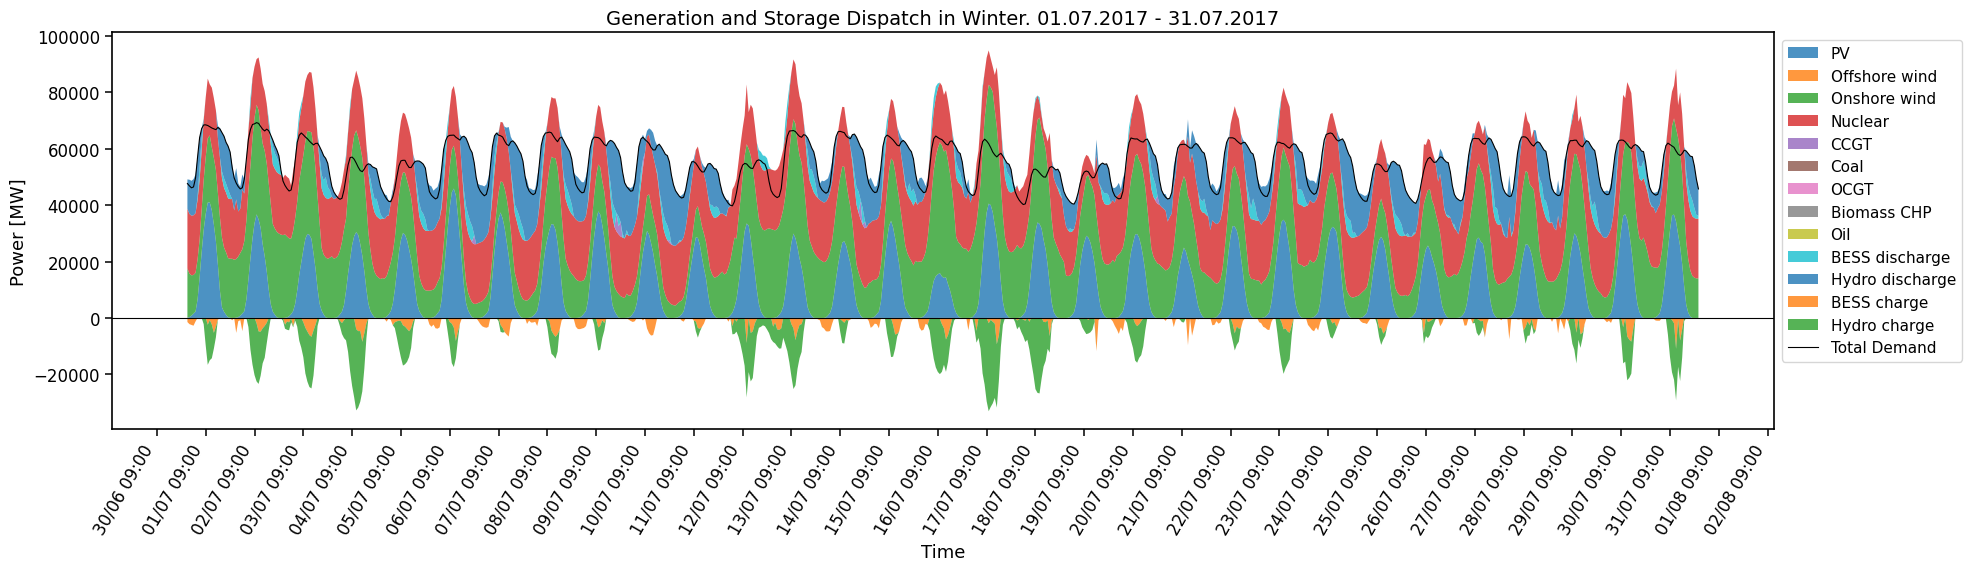

In [36]:
start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
end_date   = pd.Timestamp(f"{capacity_factor_year}-07-31 23:00:00")
tech_colors = {
    # Core technologies
    "PV": "#E7B800",
    "Onshore wind": "#407E2D",
    "Offshore wind": "#A00078",
    "Biomass CHP": "#8C564B",
    "CCGT": "#553375",
    "OCGT": "#851B35",
    "Coal": "#7E8083",
    "Oil": "#272727",

    # Storage (standardized naming)
    "BESS": "#E6810E",
    "Battery": "#E6810E",              # fallback if appears
    "BESS discharge": "#E6810E",
    "BESS charge": "#E6810E",
    "Battery discharge": "#E6810E",
    "Battery charge": "#E6810E",

    # Other generation
    "Hydro": "#3C78D8",                # adjusted to fit palette better
    "Nuclear": "#790C0C",

    # System variables
    "Demand": "#000000",
    "Net import": "#000000",
}
# ----------------------------
# GENERATORS
# ----------------------------
dispatch = n2.generators_t.p.copy()

carrier_series = n2.generators.carrier
nice_name_map = n2.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)
dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost ordering for generators
cost_df = n2.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n2.carriers.nice_name)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()
tech_order = cost_by_tech.sort_values().index.tolist()

dispatch_nice = dispatch_nice[tech_order]

# ----------------------------
# STORAGE UNITS
# ----------------------------
# Positive = discharge, negative = charge
storage_p = n2.storage_units_t.p.copy()

if not storage_p.empty:
    storage_nice_map = n2.storage_units.carrier.map(n2.carriers.nice_name).to_dict()

    storage_nice = storage_p.rename(
        columns=lambda s: storage_nice_map.get(s, s)
    )
    storage_nice = storage_nice.T.groupby(level=0).sum().T

    storage_discharge = storage_nice.clip(lower=0)
    storage_charge = storage_nice.clip(upper=0)
else:
    storage_discharge = pd.DataFrame(index=dispatch_nice.index)
    storage_charge = pd.DataFrame(index=dispatch_nice.index)

# ----------------------------
# SLICE TIME
# ----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_cols = ["el_demand_dk", "el_demand_no", "el_demand_swe", "el_demand_gbr"]
demand_plot = work_df.loc[start_date:end_date, demand_cols].sum(axis=1).copy()
storage_discharge_plot = storage_discharge.loc[start_date:end_date].copy()
storage_charge_plot = storage_charge.loc[start_date:end_date].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)
storage_discharge_plot.index = pd.to_datetime(storage_discharge_plot.index)
storage_charge_plot.index = pd.to_datetime(storage_charge_plot.index)

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(20, 6))
x = dispatch_plot.index

# Positive stack: generators first
pos_cum = np.zeros(len(x))
for col in dispatch_plot.columns:
    y = dispatch_plot[col].to_numpy()
    ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=col)
    pos_cum = pos_cum + y

# Positive stack: storage discharge on top
for col in storage_discharge_plot.columns:
    y = storage_discharge_plot[col].to_numpy()
    if np.any(y != 0):
        ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=f"{col} discharge")
        pos_cum = pos_cum + y

# Negative stack: storage charging below zero
neg_cum = np.zeros(len(x))
for col in storage_charge_plot.columns:
    y = storage_charge_plot[col].to_numpy()  # negative or zero
    if np.any(y != 0):
        ax.fill_between(x, neg_cum, neg_cum + y, alpha=0.8, label=f"{col} charge")
        neg_cum = neg_cum + y

# Demand line
ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.8,
    color="black",
    label="Total Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
        f"Generation and Storage Dispatch in Winter. "
        f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
    )
else:
    ax.set_title("Generation and Storage Dispatch in Winter. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### D Plots

FileNotFoundError: [Errno 2] No such file or directory: 'V2/winter_dispatch_2x2_shared_legend.png'

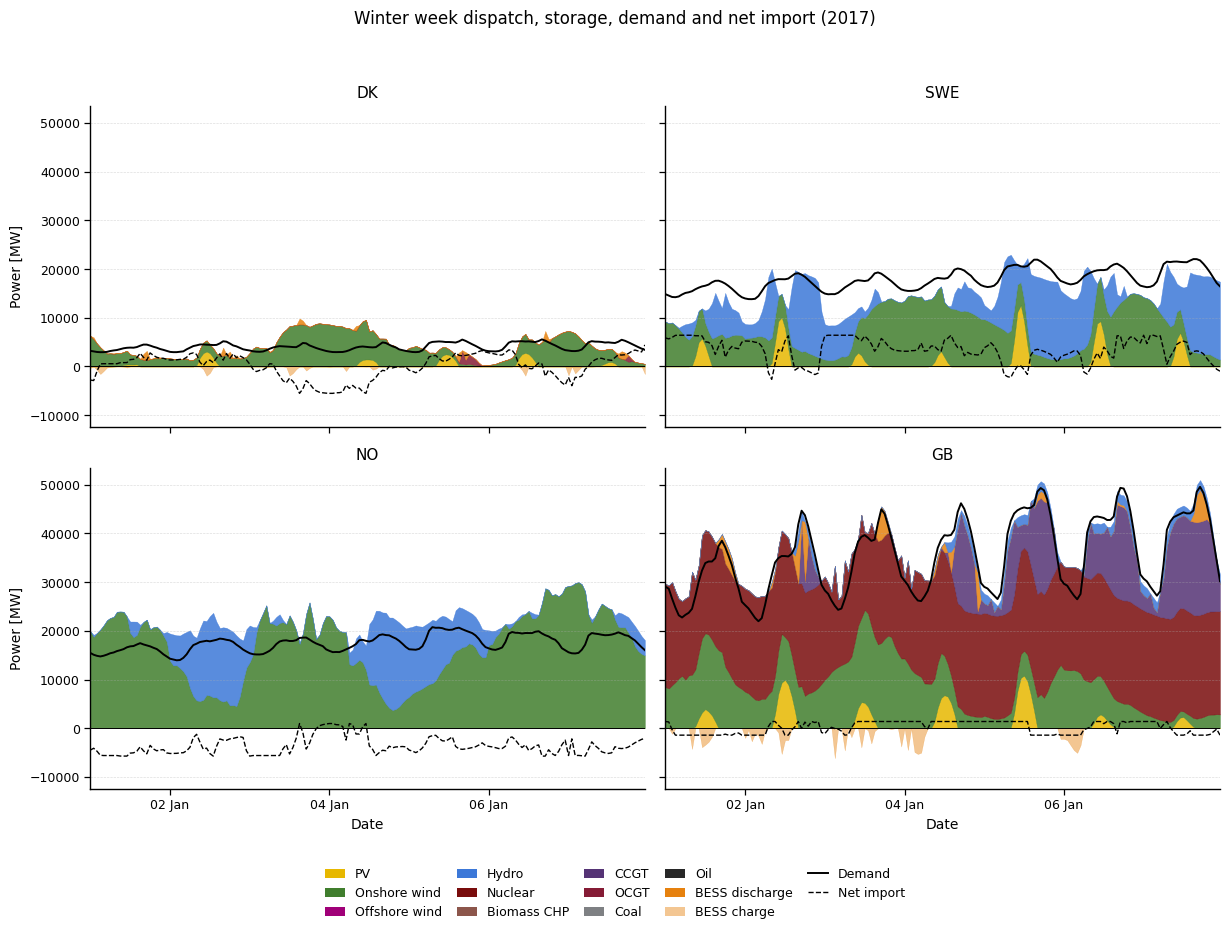

In [47]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# ----------------------------
# CONSISTENT COLORS
# ----------------------------
tech_colors = {
    # Core technologies
    "PV": "#E7B800",
    "Onshore wind": "#407E2D",
    "Offshore wind": "#A00078",
    "Biomass CHP": "#8C564B",
    "CCGT": "#553375",
    "OCGT": "#851B35",
    "Coal": "#7E8083",
    "Oil": "#272727",

    # Storage
    "BESS": "#E6810E",
    "Battery": "#E6810E",
    "BESS discharge": "#E6810E",
    "BESS charge": "#E6810E",
    "Battery discharge": "#E6810E",
    "Battery charge": "#E6810E",

    # Other generation
    "Hydro": "#3C78D8",
    "Nuclear": "#790C0C",

    # System variables
    "Demand": "#000000",
    "Net import": "#000000",
}

# ----------------------------
# GLOBAL STYLE
# ----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# ----------------------------
# TIME WINDOW - WINTER
# ----------------------------
start_date = pd.Timestamp(f"{capacity_factor_year}-01-01 00:00:00")
end_date   = pd.Timestamp(f"{capacity_factor_year}-01-07 23:00:00")

countries = ["DK", "SWE", "NO", "GB"]

# ----------------------------
# DATA WINDOWS
# ----------------------------
gen_dispatch = n2.generators_t.p.loc[start_date:end_date].copy()
storage_dispatch = n2.storage_units_t.p.loc[start_date:end_date].copy()
load_dispatch = n2.loads_t.p_set.loc[start_date:end_date].copy()
line_p0 = n2.lines_t.p0.loc[start_date:end_date].copy()

gen_meta = n2.generators[["bus", "carrier", "marginal_cost"]].copy()
gen_meta["nice_name"] = gen_meta["carrier"].map(n2.carriers.nice_name).fillna(gen_meta["carrier"])

if not storage_dispatch.empty:
    su_meta = n2.storage_units[["bus", "carrier"]].copy()
    su_meta["nice_name"] = su_meta["carrier"].map(n2.carriers.nice_name).fillna(su_meta["carrier"])
else:
    su_meta = pd.DataFrame(columns=["bus", "carrier", "nice_name"])

load_meta = n2.loads[["bus"]].copy()
line_meta = n2.lines[["bus0", "bus1"]].copy()

preferred_order = [
    "PV",
    "Onshore wind",
    "Offshore wind",
    "Hydro",
    "Nuclear",
    "Biomass CHP",
    "CCGT",
    "OCGT",
    "Coal",
    "Oil",
]

# ----------------------------
# HELPER FUNCTIONS
# ----------------------------
def get_country_generation(country):
    gens = gen_meta.index[gen_meta["bus"] == country]
    if len(gens) == 0:
        return pd.DataFrame(index=gen_dispatch.index)

    df = gen_dispatch[gens].copy()
    rename_map = gen_meta.loc[gens, "nice_name"].to_dict()
    df = df.rename(columns=rename_map)
    df = df.T.groupby(level=0).sum().T

    ordered_cols = [c for c in preferred_order if c in df.columns]
    remaining = [c for c in df.columns if c not in ordered_cols]
    df = df[ordered_cols + remaining]

    active_cols = [c for c in df.columns if np.any(np.abs(df[c].to_numpy()) > 1e-9)]
    return df[active_cols]


def get_country_storage(country):
    sus = su_meta.index[su_meta["bus"] == country]
    if len(sus) == 0:
        empty = pd.DataFrame(index=gen_dispatch.index)
        return empty, empty

    df = storage_dispatch[sus].copy()
    rename_map = su_meta.loc[sus, "nice_name"].to_dict()
    df = df.rename(columns=rename_map)
    df = df.T.groupby(level=0).sum().T

    discharge = df.clip(lower=0)
    charge = df.clip(upper=0)

    if not discharge.empty:
        discharge = discharge[[c for c in discharge.columns if np.any(np.abs(discharge[c].to_numpy()) > 1e-9)]]
    if not charge.empty:
        charge = charge[[c for c in charge.columns if np.any(np.abs(charge[c].to_numpy()) > 1e-9)]]

    return discharge, charge


def get_country_demand(country):
    loads = load_meta.index[load_meta["bus"] == country]
    if len(loads) == 0:
        return pd.Series(0.0, index=gen_dispatch.index, name=f"{country}_demand")
    return load_dispatch[loads].sum(axis=1)


def get_country_net_import(country):
    net_import = pd.Series(0.0, index=line_p0.index)

    for line in line_meta.index:
        bus0 = line_meta.loc[line, "bus0"]
        bus1 = line_meta.loc[line, "bus1"]
        p0 = line_p0[line]

        if country == bus0:
            net_import = net_import - p0
        elif country == bus1:
            net_import = net_import + p0

    return net_import


# ----------------------------
# PRECOMPUTE COMMON Y-LIMITS
# ----------------------------
country_data = {}
global_ymax = 0.0
global_ymin = 0.0

for country in countries:
    gen_df = get_country_generation(country)
    storage_discharge_df, storage_charge_df = get_country_storage(country)
    demand = get_country_demand(country)
    net_import = get_country_net_import(country)

    pos_total = pd.Series(0.0, index=demand.index)
    neg_total = pd.Series(0.0, index=demand.index)

    if not gen_df.empty:
        pos_total = pos_total.add(gen_df.sum(axis=1), fill_value=0.0)
    if not storage_discharge_df.empty:
        pos_total = pos_total.add(storage_discharge_df.sum(axis=1), fill_value=0.0)
    if not storage_charge_df.empty:
        neg_total = neg_total.add(storage_charge_df.sum(axis=1), fill_value=0.0)  # negative values

    local_ymax = max(pos_total.max(), demand.max(), net_import.max())
    local_ymin = min(neg_total.min(), net_import.min(), 0.0)

    global_ymax = max(global_ymax, local_ymax)
    global_ymin = min(global_ymin, local_ymin)

    country_data[country] = {
        "gen_df": gen_df,
        "storage_discharge_df": storage_discharge_df,
        "storage_charge_df": storage_charge_df,
        "demand": demand,
        "net_import": net_import,
    }

global_ymax *= 1.05
global_ymin *= 1.05

# ----------------------------
# 2x2 FIGURE
# ----------------------------
# Two panels side by side ~ twice the width, and two rows
fig, axes = plt.subplots(2, 2, figsize=(12.4, 9.3), sharex=True, sharey=True)
axes = axes.flatten()

for ax, country in zip(axes, countries):
    gen_df = country_data[country]["gen_df"]
    storage_discharge_df = country_data[country]["storage_discharge_df"]
    storage_charge_df = country_data[country]["storage_charge_df"]
    demand = country_data[country]["demand"]
    net_import = country_data[country]["net_import"]

    x = demand.index

    # Positive stack: generation
    pos_cum = np.zeros(len(x))
    for col in gen_df.columns:
        y = gen_df[col].to_numpy()
        color = tech_colors.get(col, "#999999")
        ax.fill_between(
            x, pos_cum, pos_cum + y,
            color=color, alpha=0.85, linewidth=0.25
        )
        pos_cum = pos_cum + y

    # Positive stack: storage discharge
    for col in storage_discharge_df.columns:
        y = storage_discharge_df[col].to_numpy()

        if col == "Hydro":
            color = tech_colors["Hydro"]
        elif col in ["Battery", "BESS"]:
            color = tech_colors["BESS discharge"]
        else:
            color = tech_colors.get(f"{col} discharge", tech_colors.get(col, "#999999"))

        ax.fill_between(
            x, pos_cum, pos_cum + y,
            color=color, alpha=0.85, linewidth=0.25
        )
        pos_cum = pos_cum + y

    # Negative stack: storage charge
    neg_cum = np.zeros(len(x))
    for col in storage_charge_df.columns:
        if col == "Hydro":
            continue

        y = storage_charge_df[col].to_numpy()

        if col in ["Battery", "BESS"]:
            color = tech_colors["BESS charge"]
        else:
            color = tech_colors.get(f"{col} charge", tech_colors.get(col, "#999999"))

        ax.fill_between(
            x, neg_cum, neg_cum + y,
            color=color, alpha=0.45, linewidth=0.25
        )
        neg_cum = neg_cum + y

    # Demand
    ax.plot(
        x, demand.to_numpy(),
        color=tech_colors["Demand"],
        linewidth=1.4,
        zorder=5
    )

    # Net import
    ax.plot(
        x, net_import.to_numpy(),
        linestyle="--",
        linewidth=1.0,
        color=tech_colors["Net import"],
        zorder=6
    )

    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_title(country, pad=6)
    ax.set_ylim(global_ymin, global_ymax)
    ax.margins(x=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.45, alpha=0.45)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# Axis labels only where needed
axes[0].set_ylabel("Power [MW]")
axes[2].set_ylabel("Power [MW]")
axes[2].set_xlabel("Date")
axes[3].set_xlabel("Date")

# ----------------------------
# SHARED LEGEND
# ----------------------------
legend_handles = [
    Patch(facecolor=tech_colors["PV"], edgecolor="none", label="PV"),
    Patch(facecolor=tech_colors["Onshore wind"], edgecolor="none", label="Onshore wind"),
    Patch(facecolor=tech_colors["Offshore wind"], edgecolor="none", label="Offshore wind"),
    Patch(facecolor=tech_colors["Hydro"], edgecolor="none", label="Hydro"),
    Patch(facecolor=tech_colors["Nuclear"], edgecolor="none", label="Nuclear"),
    Patch(facecolor=tech_colors["Biomass CHP"], edgecolor="none", label="Biomass CHP"),
    Patch(facecolor=tech_colors["CCGT"], edgecolor="none", label="CCGT"),
    Patch(facecolor=tech_colors["OCGT"], edgecolor="none", label="OCGT"),
    Patch(facecolor=tech_colors["Coal"], edgecolor="none", label="Coal"),
    Patch(facecolor=tech_colors["Oil"], edgecolor="none", label="Oil"),
    Patch(facecolor=tech_colors["BESS discharge"], edgecolor="none", label="BESS discharge"),
    Patch(facecolor=tech_colors["BESS charge"], edgecolor="none", alpha=0.45, label="BESS charge"),
    Line2D([0], [0], color=tech_colors["Demand"], lw=1.4, label="Demand"),
    Line2D([0], [0], color=tech_colors["Net import"], lw=1.0, linestyle="--", label="Net import"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=5,
    frameon=False,
    handlelength=1.6,
    columnspacing=1.2
)

fig.suptitle("Winter week dispatch, storage, demand and net import (2017)", y=0.98, fontsize=12)

fig.tight_layout(rect=[0, 0.08, 1, 0.95])

# Save single PNG
fig.savefig("V2/winter_dispatch_2x2_shared_legend.png", dpi=300, bbox_inches="tight")
plt.show()

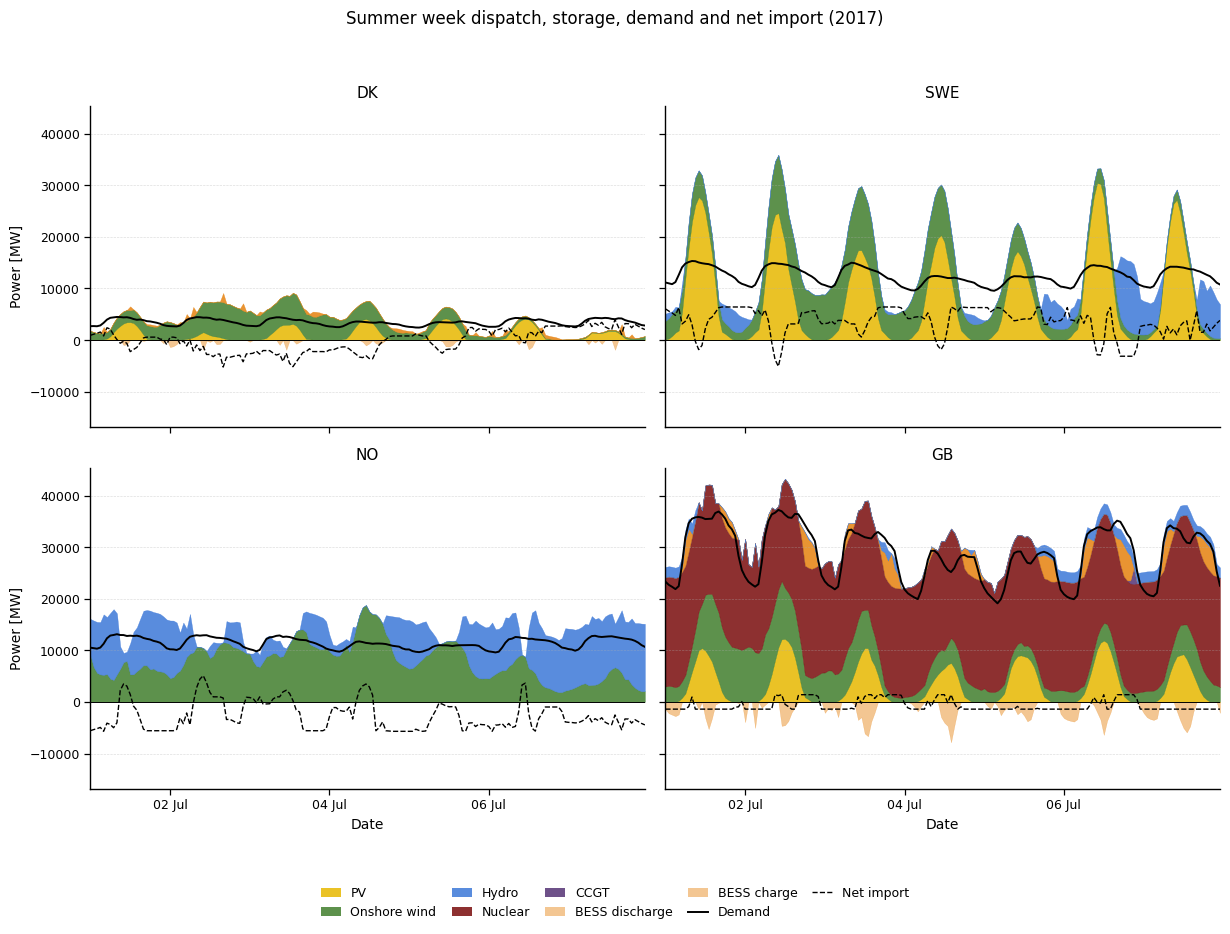

In [50]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# ----------------------------
# CONSISTENT COLORS
# ----------------------------
tech_colors = {
    # Core technologies
    "PV": "#E7B800",
    "Onshore wind": "#407E2D",
    "Offshore wind": "#A00078",
    "Biomass CHP": "#8C564B",
    "CCGT": "#553375",
    "OCGT": "#851B35",
    "Coal": "#7E8083",
    "Oil": "#272727",

    # Storage
    "BESS": "#E6810E",
    "Battery": "#E6810E",
    "BESS discharge": "#E6810E",
    "BESS charge": "#E6810E",
    "Battery discharge": "#E6810E",
    "Battery charge": "#E6810E",

    # Other generation
    "Hydro": "#3C78D8",
    "Nuclear": "#790C0C",

    # System variables
    "Demand": "#000000",
    "Net import": "#000000",
}

# ----------------------------
# GLOBAL STYLE
# ----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# ----------------------------
# TIME WINDOW - SUMMER
# ----------------------------
start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
end_date   = pd.Timestamp(f"{capacity_factor_year}-07-07 23:00:00")

countries = ["DK", "SWE", "NO", "GB"]

# ----------------------------
# DATA WINDOWS
# ----------------------------
gen_dispatch = n2.generators_t.p.loc[start_date:end_date].copy()
storage_dispatch = n2.storage_units_t.p.loc[start_date:end_date].copy()
load_dispatch = n2.loads_t.p_set.loc[start_date:end_date].copy()
line_p0 = n2.lines_t.p0.loc[start_date:end_date].copy()

gen_meta = n2.generators[["bus", "carrier", "marginal_cost"]].copy()
gen_meta["nice_name"] = gen_meta["carrier"].map(n2.carriers.nice_name).fillna(gen_meta["carrier"])

if not storage_dispatch.empty:
    su_meta = n2.storage_units[["bus", "carrier"]].copy()
    su_meta["nice_name"] = su_meta["carrier"].map(n2.carriers.nice_name).fillna(su_meta["carrier"])
else:
    su_meta = pd.DataFrame(columns=["bus", "carrier", "nice_name"])

load_meta = n2.loads[["bus"]].copy()
line_meta = n2.lines[["bus0", "bus1"]].copy()

preferred_order = [
    "PV",
    "Onshore wind",
    "Offshore wind",
    "Hydro",
    "Nuclear",
    "Biomass CHP",
    "CCGT",
    "OCGT",
    "Coal",
    "Oil",
]

# ----------------------------
# HELPER FUNCTIONS
# ----------------------------
def get_country_generation(country):
    gens = gen_meta.index[gen_meta["bus"] == country]
    if len(gens) == 0:
        return pd.DataFrame(index=gen_dispatch.index)

    df = gen_dispatch[gens].copy()
    rename_map = gen_meta.loc[gens, "nice_name"].to_dict()
    df = df.rename(columns=rename_map)
    df = df.T.groupby(level=0).sum().T

    ordered_cols = [c for c in preferred_order if c in df.columns]
    remaining = [c for c in df.columns if c not in ordered_cols]
    df = df[ordered_cols + remaining]

    active_cols = [c for c in df.columns if np.any(np.abs(df[c].to_numpy()) > 1e-9)]
    return df[active_cols]


def get_country_storage(country):
    sus = su_meta.index[su_meta["bus"] == country]
    if len(sus) == 0:
        empty = pd.DataFrame(index=gen_dispatch.index)
        return empty, empty

    df = storage_dispatch[sus].copy()
    rename_map = su_meta.loc[sus, "nice_name"].to_dict()
    df = df.rename(columns=rename_map)
    df = df.T.groupby(level=0).sum().T

    discharge = df.clip(lower=0)
    charge = df.clip(upper=0)

    if not discharge.empty:
        discharge = discharge[[c for c in discharge.columns if np.any(np.abs(discharge[c].to_numpy()) > 1e-9)]]
    if not charge.empty:
        charge = charge[[c for c in charge.columns if np.any(np.abs(charge[c].to_numpy()) > 1e-9)]]

    return discharge, charge


def get_country_demand(country):
    loads = load_meta.index[load_meta["bus"] == country]
    if len(loads) == 0:
        return pd.Series(0.0, index=gen_dispatch.index, name=f"{country}_demand")
    return load_dispatch[loads].sum(axis=1)


def get_country_net_import(country):
    net_import = pd.Series(0.0, index=line_p0.index)

    for line in line_meta.index:
        bus0 = line_meta.loc[line, "bus0"]
        bus1 = line_meta.loc[line, "bus1"]
        p0 = line_p0[line]

        if country == bus0:
            net_import = net_import - p0
        elif country == bus1:
            net_import = net_import + p0

    return net_import


# ----------------------------
# PRECOMPUTE COMMON Y-LIMITS
# ----------------------------
country_data = {}
global_ymax = 0.0
global_ymin = 0.0
used_labels = set()

for country in countries:
    gen_df = get_country_generation(country)
    storage_discharge_df, storage_charge_df = get_country_storage(country)
    demand = get_country_demand(country)
    net_import = get_country_net_import(country)

    pos_total = pd.Series(0.0, index=demand.index)
    neg_total = pd.Series(0.0, index=demand.index)

    if not gen_df.empty:
        pos_total = pos_total.add(gen_df.sum(axis=1), fill_value=0.0)
        used_labels.update(gen_df.columns.tolist())

    if not storage_discharge_df.empty:
        pos_total = pos_total.add(storage_discharge_df.sum(axis=1), fill_value=0.0)
        for col in storage_discharge_df.columns:
            if col == "Hydro":
                used_labels.add("Hydro")
            elif col in ["Battery", "BESS"]:
                used_labels.add("BESS discharge")
            else:
                used_labels.add(f"{col} discharge")

    if not storage_charge_df.empty:
        neg_total = neg_total.add(storage_charge_df.sum(axis=1), fill_value=0.0)
        for col in storage_charge_df.columns:
            if col == "Hydro":
                continue
            elif col in ["Battery", "BESS"]:
                used_labels.add("BESS charge")
            else:
                used_labels.add(f"{col} charge")

    used_labels.add("Demand")
    used_labels.add("Net import")

    local_ymax = max(pos_total.max(), demand.max(), net_import.max())
    local_ymin = min(neg_total.min(), net_import.min(), 0.0)

    global_ymax = max(global_ymax, local_ymax)
    global_ymin = min(global_ymin, local_ymin)

    country_data[country] = {
        "gen_df": gen_df,
        "storage_discharge_df": storage_discharge_df,
        "storage_charge_df": storage_charge_df,
        "demand": demand,
        "net_import": net_import,
    }

global_ymax *= 1.05
global_ymin *= 1.05

# ----------------------------
# 2x2 FIGURE
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12.4, 9.3), sharex=True, sharey=True)
axes = axes.flatten()

for ax, country in zip(axes, countries):
    gen_df = country_data[country]["gen_df"]
    storage_discharge_df = country_data[country]["storage_discharge_df"]
    storage_charge_df = country_data[country]["storage_charge_df"]
    demand = country_data[country]["demand"]
    net_import = country_data[country]["net_import"]

    x = demand.index

    # Positive stack: generation
    pos_cum = np.zeros(len(x))
    for col in gen_df.columns:
        y = gen_df[col].to_numpy()
        color = tech_colors.get(col, "#999999")
        ax.fill_between(
            x, pos_cum, pos_cum + y,
            color=color, alpha=0.85, linewidth=0.25
        )
        pos_cum = pos_cum + y

    # Positive stack: storage discharge
    for col in storage_discharge_df.columns:
        y = storage_discharge_df[col].to_numpy()

        if col == "Hydro":
            color = tech_colors["Hydro"]
        elif col in ["Battery", "BESS"]:
            color = tech_colors["BESS discharge"]
        else:
            color = tech_colors.get(f"{col} discharge", tech_colors.get(col, "#999999"))

        ax.fill_between(
            x, pos_cum, pos_cum + y,
            color=color, alpha=0.85, linewidth=0.25
        )
        pos_cum = pos_cum + y

    # Negative stack: storage charge
    neg_cum = np.zeros(len(x))
    for col in storage_charge_df.columns:
        if col == "Hydro":
            continue

        y = storage_charge_df[col].to_numpy()

        if col in ["Battery", "BESS"]:
            color = tech_colors["BESS charge"]
        else:
            color = tech_colors.get(f"{col} charge", tech_colors.get(col, "#999999"))

        ax.fill_between(
            x, neg_cum, neg_cum + y,
            color=color, alpha=0.45, linewidth=0.25
        )
        neg_cum = neg_cum + y

    # Demand
    ax.plot(
        x, demand.to_numpy(),
        color=tech_colors["Demand"],
        linewidth=1.4,
        zorder=5
    )

    # Net import
    ax.plot(
        x, net_import.to_numpy(),
        linestyle="--",
        linewidth=1.0,
        color=tech_colors["Net import"],
        zorder=6
    )

    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_title(country, pad=6)
    ax.set_ylim(global_ymin, global_ymax)
    ax.margins(x=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.45, alpha=0.45)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# Axis labels only where needed
axes[0].set_ylabel("Power [MW]")
axes[2].set_ylabel("Power [MW]")
axes[2].set_xlabel("Date")
axes[3].set_xlabel("Date")

# ----------------------------
# SHARED LEGEND - DYNAMIC
# ----------------------------
legend_priority = [
    "PV",
    "Onshore wind",
    "Offshore wind",
    "Hydro",
    "Nuclear",
    "Biomass CHP",
    "CCGT",
    "OCGT",
    "Coal",
    "Oil",
    "BESS discharge",
    "BESS charge",
    "Demand",
    "Net import",
]

legend_handles = []
for label in legend_priority:
    if label not in used_labels:
        continue

    if label in ["Demand", "Net import"]:
        handle = Line2D(
            [0], [0],
            color=tech_colors[label],
            lw=1.4 if label == "Demand" else 1.0,
            linestyle="-" if label == "Demand" else "--",
            label=label
        )
    else:
        handle = Patch(
            facecolor=tech_colors.get(label, "#999999"),
            edgecolor="none",
            alpha=0.45 if "charge" in label else 0.85,
            label=label
        )

    legend_handles.append(handle)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=5,
    frameon=False,
    handlelength=1.6,
    columnspacing=1.2
)

fig.suptitle("Summer week dispatch, storage, demand and net import (2017)", y=0.98, fontsize=12)

fig.tight_layout(rect=[0, 0.08, 1, 0.95])

# Optional save
# fig.savefig("V2/summer_dispatch_2x2_shared_legend.png", dpi=300, bbox_inches="tight")

plt.show()


#### Winter Plot

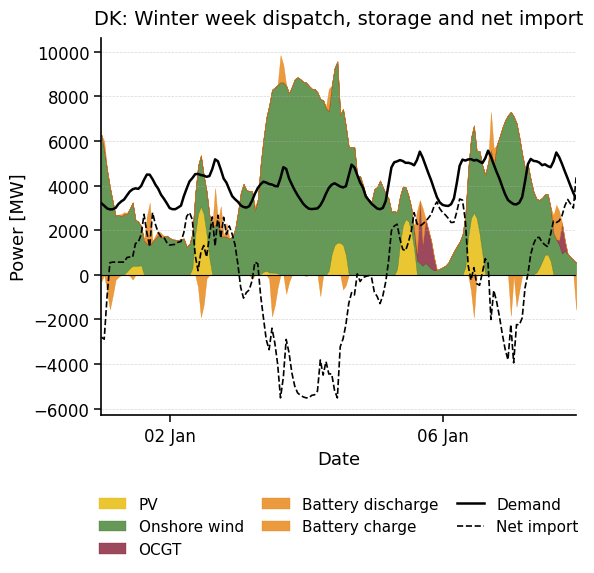

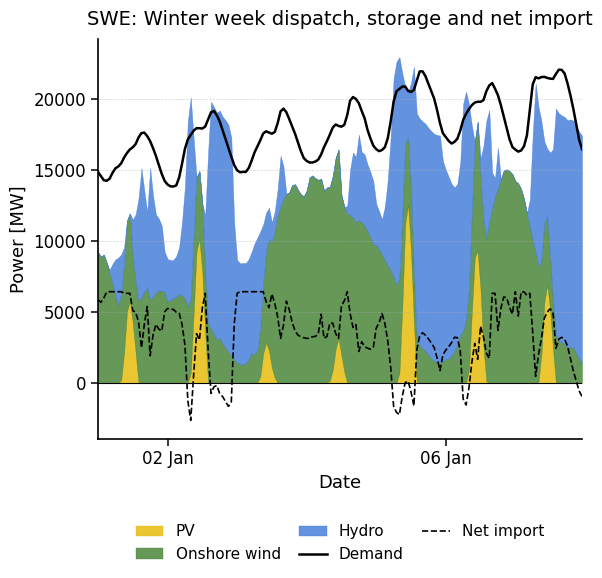

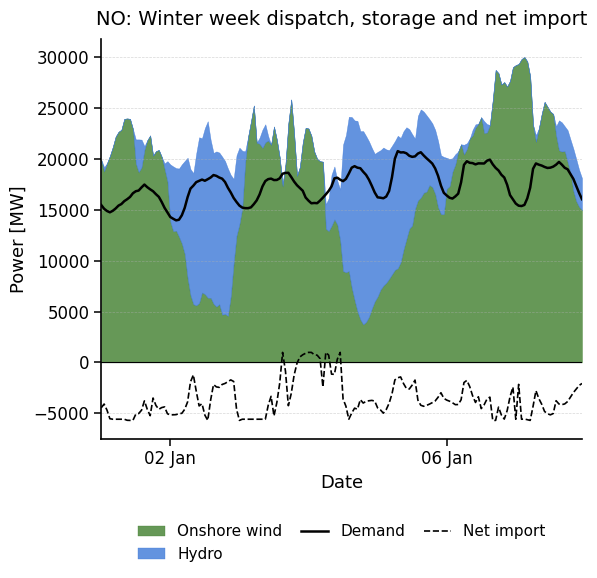

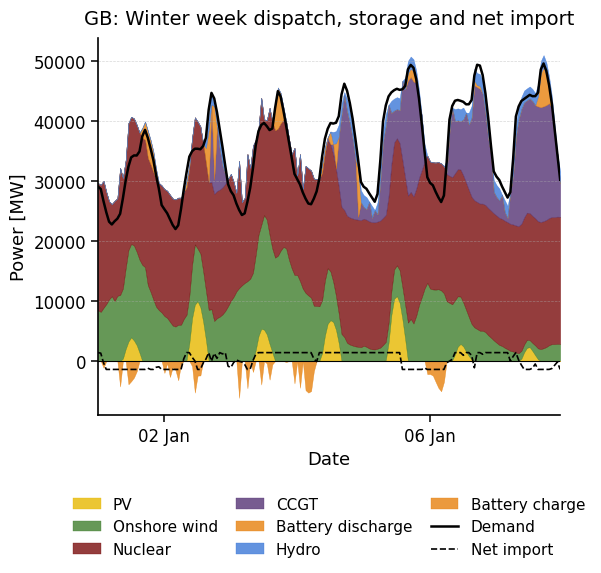

In [38]:
# Winter
# ----------------------------
# CONSISTENT COLORS
# ----------------------------
tech_colors = {
    # Core technologies
    "PV": "#E7B800",
    "Onshore wind": "#407E2D",
    "Offshore wind": "#A00078",
    "Biomass CHP": "#8C564B",
    "CCGT": "#553375",
    "OCGT": "#851B35",
    "Coal": "#7E8083",
    "Oil": "#272727",

    # Storage (standardized naming)
    "BESS": "#E6810E",
    "Battery": "#E6810E",              # fallback if appears
    "BESS discharge": "#E6810E",
    "BESS charge": "#E6810E",
    "Battery discharge": "#E6810E",
    "Battery charge": "#E6810E",

    # Other generation
    "Hydro": "#3C78D8",                # adjusted to fit palette better
    "Nuclear": "#790C0C",

    # System variables
    "Demand": "#000000",
    "Net import": "#000000",
}

# ----------------------------
# TIME WINDOW
# ----------------------------
start_date = pd.Timestamp(f"{capacity_factor_year}-01-01 00:00:00")
end_date   = pd.Timestamp(f"{capacity_factor_year}-01-07 23:00:00")

countries = ["DK", "SWE", "NO", "GB"]

# ----------------------------
# GENERATOR DISPATCH BY COUNTRY AND TECH
# ----------------------------
gen_dispatch = n2.generators_t.p.loc[start_date:end_date].copy()

gen_meta = n2.generators[["bus", "carrier", "marginal_cost"]].copy()
gen_meta["nice_name"] = gen_meta["carrier"].map(n2.carriers.nice_name).fillna(gen_meta["carrier"])

tech_order = (
    gen_meta.groupby("nice_name")["marginal_cost"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

# ----------------------------
# STORAGE BY COUNTRY AND TECH
# ----------------------------
storage_dispatch = n2.storage_units_t.p.loc[start_date:end_date].copy()

if not storage_dispatch.empty:
    su_meta = n2.storage_units[["bus", "carrier"]].copy()
    su_meta["nice_name"] = su_meta["carrier"].map(n2.carriers.nice_name).fillna(su_meta["carrier"])
else:
    su_meta = pd.DataFrame(columns=["bus", "carrier", "nice_name"])

# ----------------------------
# LOAD BY COUNTRY
# ----------------------------
load_dispatch = n2.loads_t.p_set.loc[start_date:end_date].copy()
load_meta = n2.loads[["bus"]].copy()

# ----------------------------
# LINE FLOWS
# ----------------------------
line_p0 = n2.lines_t.p0.loc[start_date:end_date].copy()
line_meta = n2.lines[["bus0", "bus1"]].copy()

# ----------------------------
# HELPER FUNCTIONS
# ----------------------------
def get_country_generation(country):
    gens = gen_meta.index[gen_meta["bus"] == country]
    if len(gens) == 0:
        return pd.DataFrame(index=gen_dispatch.index)

    df = gen_dispatch[gens].copy()
    rename_map = gen_meta.loc[gens, "nice_name"].to_dict()
    df = df.rename(columns=rename_map)
    df = df.T.groupby(level=0).sum().T

    ordered_cols = [c for c in tech_order if c in df.columns]
    return df[ordered_cols]

def get_country_storage(country):
    sus = su_meta.index[su_meta["bus"] == country]
    if len(sus) == 0:
        empty = pd.DataFrame(index=gen_dispatch.index)
        return empty, empty

    df = storage_dispatch[sus].copy()
    rename_map = su_meta.loc[sus, "nice_name"].to_dict()
    df = df.rename(columns=rename_map)
    df = df.T.groupby(level=0).sum().T

    discharge = df.clip(lower=0)
    charge = df.clip(upper=0)
    return discharge, charge

def get_country_demand(country):
    loads = load_meta.index[load_meta["bus"] == country]
    if len(loads) == 0:
        return pd.Series(0.0, index=gen_dispatch.index, name=f"{country}_demand")

    return load_dispatch[loads].sum(axis=1)

def get_country_net_import(country):
    net_import = pd.Series(0.0, index=line_p0.index)

    for line in line_meta.index:
        bus0 = line_meta.loc[line, "bus0"]
        bus1 = line_meta.loc[line, "bus1"]
        p0 = line_p0[line]

        # p0 > 0 means flow bus0 -> bus1
        if country == bus0:
            net_import = net_import - p0
        elif country == bus1:
            net_import = net_import + p0

    return net_import

# ----------------------------
# ONE SQUARE FIGURE PER COUNTRY
# ----------------------------
for country in countries:
    gen_df = get_country_generation(country)
    storage_discharge_df, storage_charge_df = get_country_storage(country)
    demand = get_country_demand(country)
    net_import = get_country_net_import(country)

    x = gen_df.index if not gen_df.empty else demand.index

    fig, ax = plt.subplots(figsize=(6.2, 6.2))

    used_labels = set()

    def unique_label(label):
        if label in used_labels:
            return "_nolegend_"
        used_labels.add(label)
        return label

    # positive stack: generation
    pos_cum = np.zeros(len(x))
    for col in gen_df.columns:
        y = gen_df[col].to_numpy()
        if np.any(np.abs(y) > 1e-9):
            color = tech_colors.get(col, "lightgray")
            ax.fill_between(
                x,
                pos_cum,
                pos_cum + y,
                color=color,
                alpha=0.8,
                linewidth=0.3,
                label=unique_label(col)
            )
            pos_cum = pos_cum + y

    # positive stack: storage discharge
    for col in storage_discharge_df.columns:
        y = storage_discharge_df[col].to_numpy()
        if np.any(np.abs(y) > 1e-9):
            if col == "Hydro":
                label = "Hydro"
                color = tech_colors.get("Hydro", "lightgray")
            elif col in ["Battery", "BESS"]:
                label = "Battery discharge"
                color = tech_colors.get("Battery discharge", tech_colors.get("Battery", "lightgray"))
            else:
                label = f"{col} discharge"
                color = tech_colors.get(label, tech_colors.get(col, "lightgray"))

            ax.fill_between(
                x,
                pos_cum,
                pos_cum + y,
                color=color,
                alpha=0.8,
                linewidth=0.3,
                label=unique_label(label)
            )
            pos_cum = pos_cum + y

    # negative stack: storage charge
    neg_cum = np.zeros(len(x))
    for col in storage_charge_df.columns:
        if col == "Hydro":
            continue

        y = storage_charge_df[col].to_numpy()
        if np.any(np.abs(y) > 1e-9):
            if col in ["Battery", "BESS"]:
                label = "Battery charge"
                color = tech_colors.get("Battery charge", tech_colors.get("Battery", "lightgray"))
            else:
                label = f"{col} charge"
                color = tech_colors.get(label, tech_colors.get(col, "lightgray"))

            ax.fill_between(
                x,
                neg_cum,
                neg_cum + y,
                color=color,
                alpha=0.8,
                linewidth=0.3,
                label=unique_label(label)
            )
            neg_cum = neg_cum + y

    # demand line
    ax.plot(
        x,
        demand.to_numpy(),
        color=tech_colors["Demand"],
        linewidth=1.8,
        label=unique_label("Demand"),
        zorder=5
    )

    # net import line
    ax.plot(
        x,
        net_import.to_numpy(),
        linestyle="--",
        linewidth=1.2,
        color=tech_colors["Net import"],
        label=unique_label("Net import"),
        zorder=6
    )

    # styling
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Power [MW]")
    ax.set_xlabel("Date")
    ax.set_title(f"{country}: Winter week dispatch, storage and net import", pad=10)

    ax.margins(x=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    handles, labels = ax.get_legend_handles_labels()
    clean = [(h, l) for h, l in zip(handles, labels) if l != "_nolegend_"]
    if clean:
        handles, labels = zip(*clean)
        ax.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.18),
            ncol=3,
            frameon=False,
            handlelength=1.8,
            columnspacing=1.2
        )

    fig.tight_layout()
    plt.show()

#### Summer Plot

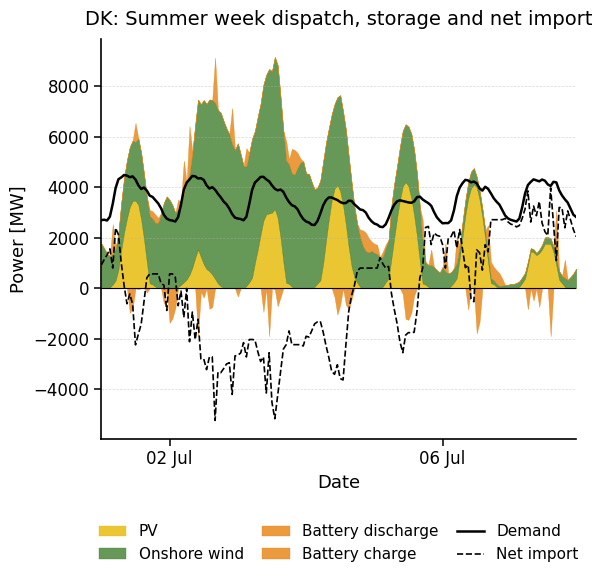

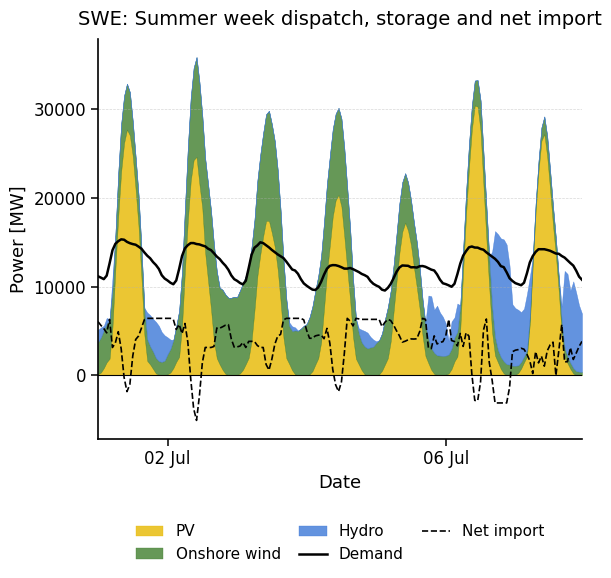

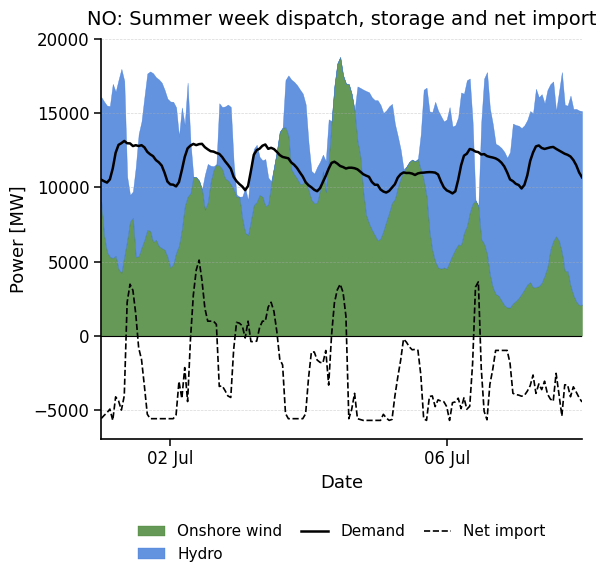

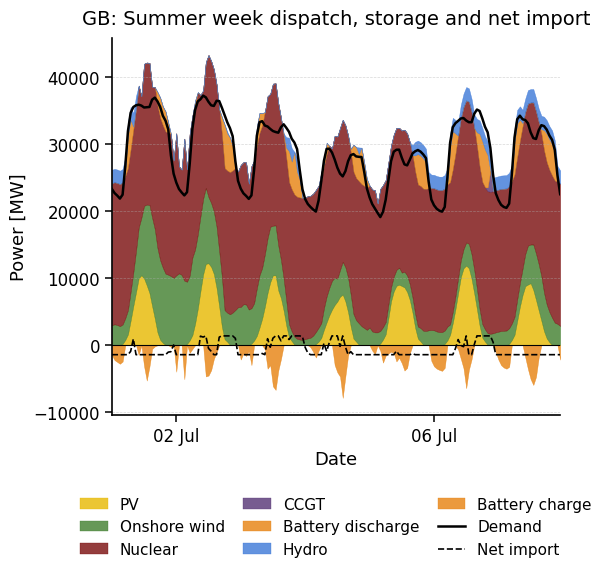

In [46]:
# Summer
# ----------------------------
# CONSISTENT COLORS
# ----------------------------
tech_colors = {
    # Core technologies
    "PV": "#E7B800",
    "Onshore wind": "#407E2D",
    "Offshore wind": "#A00078",
    "Biomass CHP": "#8C564B",
    "CCGT": "#553375",
    "OCGT": "#851B35",
    "Coal": "#7E8083",
    "Oil": "#272727",

    # Storage (standardized naming)
    "BESS": "#E6810E",
    "Battery": "#E6810E",              # fallback if appears
    "BESS discharge": "#E6810E",
    "BESS charge": "#E6810E",
    "Battery discharge": "#E6810E",
    "Battery charge": "#E6810E",

    # Other generation
    "Hydro": "#3C78D8",                # adjusted to fit palette better
    "Nuclear": "#790C0C",

    # System variables
    "Demand": "#000000",
    "Net import": "#000000",
}

# ----------------------------
# TIME WINDOW
# ----------------------------
start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
end_date   = pd.Timestamp(f"{capacity_factor_year}-07-07 23:00:00")

countries = ["DK", "SWE", "NO", "GB"]

# ----------------------------
# GENERATOR DISPATCH BY COUNTRY AND TECH
# ----------------------------
gen_dispatch = n2.generators_t.p.loc[start_date:end_date].copy()

gen_meta = n2.generators[["bus", "carrier", "marginal_cost"]].copy()
gen_meta["nice_name"] = gen_meta["carrier"].map(n2.carriers.nice_name).fillna(gen_meta["carrier"])

tech_order = (
    gen_meta.groupby("nice_name")["marginal_cost"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

# ----------------------------
# STORAGE BY COUNTRY AND TECH
# ----------------------------
storage_dispatch = n2.storage_units_t.p.loc[start_date:end_date].copy()

if not storage_dispatch.empty:
    su_meta = n2.storage_units[["bus", "carrier"]].copy()
    su_meta["nice_name"] = su_meta["carrier"].map(n2.carriers.nice_name).fillna(su_meta["carrier"])
else:
    su_meta = pd.DataFrame(columns=["bus", "carrier", "nice_name"])

# ----------------------------
# LOAD BY COUNTRY
# ----------------------------
load_dispatch = n2.loads_t.p_set.loc[start_date:end_date].copy()
load_meta = n2.loads[["bus"]].copy()

# ----------------------------
# LINE FLOWS
# ----------------------------
line_p0 = n2.lines_t.p0.loc[start_date:end_date].copy()
line_meta = n2.lines[["bus0", "bus1"]].copy()

# ----------------------------
# HELPER FUNCTIONS
# ----------------------------
def get_country_generation(country):
    gens = gen_meta.index[gen_meta["bus"] == country]
    if len(gens) == 0:
        return pd.DataFrame(index=gen_dispatch.index)

    df = gen_dispatch[gens].copy()
    rename_map = gen_meta.loc[gens, "nice_name"].to_dict()
    df = df.rename(columns=rename_map)
    df = df.T.groupby(level=0).sum().T

    ordered_cols = [c for c in tech_order if c in df.columns]
    return df[ordered_cols]

def get_country_storage(country):
    sus = su_meta.index[su_meta["bus"] == country]
    if len(sus) == 0:
        empty = pd.DataFrame(index=gen_dispatch.index)
        return empty, empty

    df = storage_dispatch[sus].copy()
    rename_map = su_meta.loc[sus, "nice_name"].to_dict()
    df = df.rename(columns=rename_map)
    df = df.T.groupby(level=0).sum().T

    discharge = df.clip(lower=0)
    charge = df.clip(upper=0)
    return discharge, charge

def get_country_demand(country):
    loads = load_meta.index[load_meta["bus"] == country]
    if len(loads) == 0:
        return pd.Series(0.0, index=gen_dispatch.index, name=f"{country}_demand")

    return load_dispatch[loads].sum(axis=1)

def get_country_net_import(country):
    net_import = pd.Series(0.0, index=line_p0.index)

    for line in line_meta.index:
        bus0 = line_meta.loc[line, "bus0"]
        bus1 = line_meta.loc[line, "bus1"]
        p0 = line_p0[line]

        # p0 > 0 means flow bus0 -> bus1
        if country == bus0:
            net_import = net_import - p0
        elif country == bus1:
            net_import = net_import + p0

    return net_import

# ----------------------------
# ONE SQUARE FIGURE PER COUNTRY
# ----------------------------
for country in countries:
    gen_df = get_country_generation(country)
    storage_discharge_df, storage_charge_df = get_country_storage(country)
    demand = get_country_demand(country)
    net_import = get_country_net_import(country)

    x = gen_df.index if not gen_df.empty else demand.index

    fig, ax = plt.subplots(figsize=(6.2, 6.2))

    used_labels = set()

    def unique_label(label):
        if label in used_labels:
            return "_nolegend_"
        used_labels.add(label)
        return label

    # positive stack: generation
    pos_cum = np.zeros(len(x))
    for col in gen_df.columns:
        y = gen_df[col].to_numpy()
        if np.any(np.abs(y) > 1e-9):
            color = tech_colors.get(col, "lightgray")
            ax.fill_between(
                x,
                pos_cum,
                pos_cum + y,
                color=color,
                alpha=0.8,
                linewidth=0.3,
                label=unique_label(col)
            )
            pos_cum = pos_cum + y

    # positive stack: storage discharge
    for col in storage_discharge_df.columns:
        y = storage_discharge_df[col].to_numpy()
        if np.any(np.abs(y) > 1e-9):
            if col == "Hydro":
                label = "Hydro"
                color = tech_colors.get("Hydro", "lightgray")
            elif col in ["Battery", "BESS"]:
                label = "Battery discharge"
                color = tech_colors.get("Battery discharge", tech_colors.get("Battery", "lightgray"))
            else:
                label = f"{col} discharge"
                color = tech_colors.get(label, tech_colors.get(col, "lightgray"))

            ax.fill_between(
                x,
                pos_cum,
                pos_cum + y,
                color=color,
                alpha=0.8,
                linewidth=0.3,
                label=unique_label(label)
            )
            pos_cum = pos_cum + y

    # negative stack: storage charge
    neg_cum = np.zeros(len(x))
    for col in storage_charge_df.columns:
        if col == "Hydro":
            continue

        y = storage_charge_df[col].to_numpy()
        if np.any(np.abs(y) > 1e-9):
            if col in ["Battery", "BESS"]:
                label = "Battery charge"
                color = tech_colors.get("Battery charge", tech_colors.get("Battery", "lightgray"))
            else:
                label = f"{col} charge"
                color = tech_colors.get(label, tech_colors.get(col, "lightgray"))

            ax.fill_between(
                x,
                neg_cum,
                neg_cum + y,
                color=color,
                alpha=0.8,
                linewidth=0.3,
                label=unique_label(label)
            )
            neg_cum = neg_cum + y

    # demand line
    ax.plot(
        x,
        demand.to_numpy(),
        color=tech_colors["Demand"],
        linewidth=1.8,
        label=unique_label("Demand"),
        zorder=5
    )

    # net import line
    ax.plot(
        x,
        net_import.to_numpy(),
        linestyle="--",
        linewidth=1.2,
        color=tech_colors["Net import"],
        label=unique_label("Net import"),
        zorder=6
    )

    # styling
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Power [MW]")
    ax.set_xlabel("Date")
    ax.set_title(f"{country}: Summer week dispatch, storage and net import", pad=10)

    ax.margins(x=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    handles, labels = ax.get_legend_handles_labels()
    clean = [(h, l) for h, l in zip(handles, labels) if l != "_nolegend_"]
    if clean:
        handles, labels = zip(*clean)
        ax.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.18),
            ncol=3,
            frameon=False,
            handlelength=1.8,
            columnspacing=1.2
        )

    fig.tight_layout()
    plt.show()

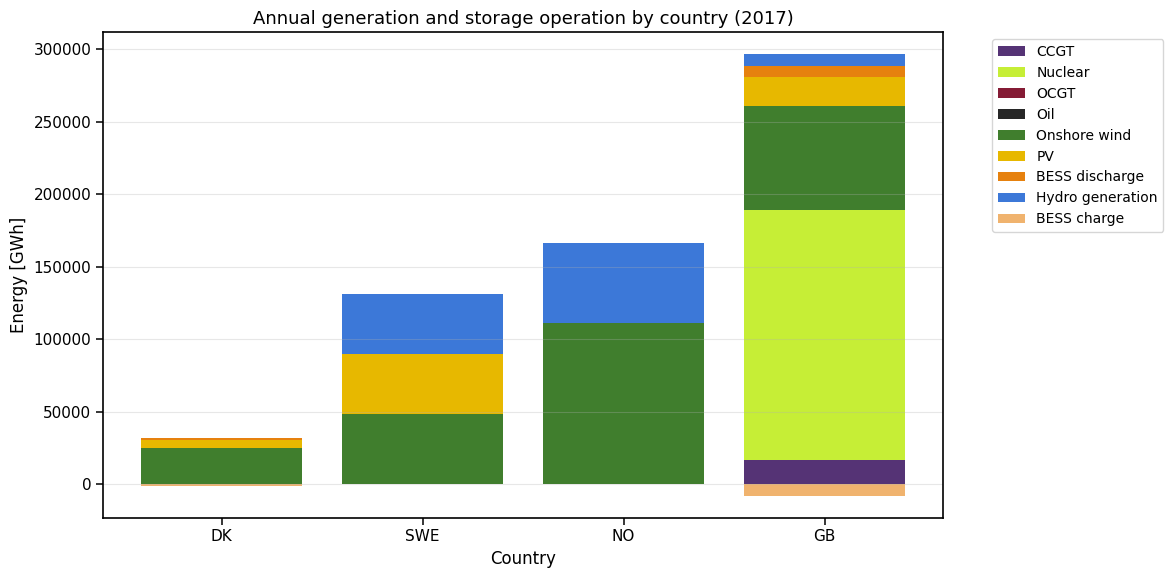

In [ ]:
# Show optimal capacities of technologies per country and how much energy each produces per year.
# ----------------------------
# CONSISTENT COLORS
# ----------------------------
tech_colors = {
    # Core technologies
    "PV": "#E7B800",
    "Onshore wind": "#407E2D",
    "Offshore wind": "#A00078",
    "Biomass CHP": "#8C564B",
    "CCGT": "#553375",
    "OCGT": "#851B35",
    "Coal": "#7E8083",
    "Oil": "#272727",

    # Storage (standardized naming)
    "BESS": "#E6810E",
    "Battery": "#E6810E",              # fallback if appears
    "BESS discharge": "#E6810E",
    "BESS charge": "#E6810E",
    "Battery discharge": "#E6810E",
    "Battery charge": "#E6810E",

    # Other generation
    "Hydro": "#3C78D8",                # adjusted to fit palette better
    "Nuclear": "#C6EE36",

    # System variables
    "Demand": "#000000",
    "Net import": "#000000",
}

# ----------------------------
# PREPARE GENERATION
# ----------------------------
gen_dispatch_raw = n2.generators_t.p.copy()

gen_meta = n2.generators[["bus", "carrier"]].copy()
nice_name_map = n2.carriers.nice_name.to_dict()

# ----------------------------
# PREPARE STORAGE
# ----------------------------
storage_dispatch_raw = n2.storage_units_t.p.copy()

if not storage_dispatch_raw.empty:
    su_meta = n2.storage_units[["bus", "carrier"]].copy()

    # Split charge / discharge from RAW data
    storage_discharge_raw = storage_dispatch_raw.clip(lower=0)
    storage_charge_raw = -storage_dispatch_raw.clip(upper=0)

else:
    su_meta = pd.DataFrame(columns=["bus", "carrier"])
    storage_discharge_raw = pd.DataFrame(index=gen_dispatch_raw.index)
    storage_charge_raw = pd.DataFrame(index=gen_dispatch_raw.index)

# ----------------------------
# BUILD COUNTRY-TECH MATRICES
# ----------------------------
countries = n2.buses.index.tolist()

gen_techs = sorted(
    set(nice_name_map.get(c, c) for c in n2.generators["carrier"].unique())
)
storage_techs = sorted(
    set(nice_name_map.get(c, c) for c in n2.storage_units["carrier"].unique())
) if not n2.storage_units.empty else []

all_techs = sorted(set(gen_techs) | set(storage_techs))

country_gen = pd.DataFrame(0.0, index=countries, columns=all_techs)
country_storage_dis = pd.DataFrame(0.0, index=countries, columns=all_techs)
country_storage_ch = pd.DataFrame(0.0, index=countries, columns=all_techs)

# --- Generators
for gen in n2.generators.index:
    country = n2.generators.loc[gen, "bus"]
    tech = nice_name_map.get(n2.generators.loc[gen, "carrier"], n2.generators.loc[gen, "carrier"])
    country_gen.loc[country, tech] += gen_dispatch_raw[gen].sum()

# --- Storage discharge
for su in n2.storage_units.index:
    country = n2.storage_units.loc[su, "bus"]
    tech = nice_name_map.get(n2.storage_units.loc[su, "carrier"], n2.storage_units.loc[su, "carrier"])
    country_storage_dis.loc[country, tech] += storage_discharge_raw[su].sum()

# --- Storage charge
for su in n2.storage_units.index:
    country = n2.storage_units.loc[su, "bus"]
    tech = nice_name_map.get(n2.storage_units.loc[su, "carrier"], n2.storage_units.loc[su, "carrier"])

    # Skip hydro charging completely
    if tech == "Hydro":
        continue

    country_storage_ch.loc[country, tech] += storage_charge_raw[su].sum()

# Convert to GWh
country_gen /= 1000
country_storage_dis /= 1000
country_storage_ch /= 1000

# Remove technologies that are zero everywhere
country_gen = country_gen.loc[:, (country_gen != 0).any(axis=0)]
country_storage_dis = country_storage_dis.loc[:, (country_storage_dis != 0).any(axis=0)]
country_storage_ch = country_storage_ch.loc[:, (country_storage_ch != 0).any(axis=0)]

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

countries_plot = country_gen.index
bottom = np.zeros(len(countries_plot))

# generation
for tech in country_gen.columns:
    values = country_gen[tech].values
    if np.any(values > 0):
        ax.bar(
            countries_plot,
            values,
            bottom=bottom,
            label=tech,
            color=tech_colors.get(tech, "lightgray")
        )
        bottom += values

# storage discharge
for tech in country_storage_dis.columns:
    values = country_storage_dis[tech].values
    if np.any(values > 0):
        label = "Hydro generation" if tech == "Hydro" else f"{tech} discharge"
        ax.bar(
            countries_plot,
            values,
            bottom=bottom,
            label=label,
            color=tech_colors.get(tech, "lightgray")
        )
        bottom += values

# storage charge (negative) -- no hydro charge
bottom_neg = np.zeros(len(countries_plot))
for tech in country_storage_ch.columns:
    values = -country_storage_ch[tech].values
    if np.any(values < 0):
        ax.bar(
            countries_plot,
            values,
            bottom=bottom_neg,
            label=f"{tech} charge",
            color=tech_colors.get(tech, "lightgray"),
            alpha=0.6
        )
        bottom_neg += values

ax.set_ylabel("Energy [GWh]")
ax.set_xlabel("Country")
ax.set_title(f"Annual generation and storage operation by country ({capacity_factor_year})")
ax.grid(axis="y", alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------
# NUMERIC TABLES PER COUNTRY AND TECHNOLOGY
# Uses:
# - country_gen
# - country_storage_dis
# - country_storage_ch
# from the previous block
# ----------------------------

# Rename for clearer presentation
country_gen_num = country_gen.copy()
country_storage_dis_num = country_storage_dis.copy()
country_storage_ch_num = country_storage_ch.copy()

# Rename storage discharge columns
country_storage_dis_num = country_storage_dis_num.rename(
    columns=lambda c: "Hydro generation" if c == "Hydro" else f"{c} discharge"
)

# Rename storage charge columns
country_storage_ch_num = country_storage_ch_num.rename(
    columns=lambda c: f"{c} charge"
)

# Combine into one table
country_energy_table = pd.concat(
    [country_gen_num, country_storage_dis_num, -country_storage_ch_num],
    axis=1
)

# Group in case names overlap
country_energy_table = country_energy_table.T.groupby(level=0).sum().T

# Round nicely
country_energy_table_rounded = country_energy_table.round(2)

print("Annual generation and storage operation by country [GWh]:")
display(country_energy_table_rounded)

Annual generation and storage operation by country [GWh]:


,BESS charge,BESS discharge,CCGT,Hydro generation,Nuclear,OCGT,Oil,Onshore wind,PV
DK,-1420.73,1309.35,0.00,0.00,0.00,148.54,0.0,24703.37,5552.09
SWE,0.00,0.00,0.00,41406.66,0.00,0.00,0.0,48174.55,41343.77
NO,0.00,0.00,0.00,55168.15,0.00,0.00,0.0,110864.29,0.00
GB,-7927.43,7305.92,16576.16,8238.00,172758.87,0.00,2.0,71165.33,20357.77


# PART E

In [41]:
first_snapshot = n2.snapshots[0]
print(first_snapshot)
line_flows_t0 = n2.lines_t.p0.loc[first_snapshot]

2017-01-01 00:00:00


In [42]:
line_flows_t0

name
DK-SWE    2415.000000
SWE-NO   -3438.157326
NO-DK     1023.157326
DK-GB     1400.000000
Name: 2017-01-01 00:00:00, dtype: float64

In [44]:
B = np.array([
    [20, -10, 0],
    [-10, 20, 0],
    [0, 0, 10]
])

Binv = np.linalg.inv(B)

Bf = np.array([
    [-10, 0, 0],
    [10, -10 ,0],
    [0, 10, 0],
    [ 0, 0, -10]
])

result = np.linalg.matmul(Bf, Binv)
result

array([[-0.66666667, -0.33333333,  0.        ],
       [ 0.33333333, -0.33333333,  0.        ],
       [ 0.33333333,  0.66666667,  0.        ],
       [ 0.        ,  0.        , -1.        ]])